# 07. 데이터 탐색: 질문 경로 Q1~Q9

## 이 노트북이 하는 일
기획 문서 2 "데이터 탐색"을 그대로 따라간다. **질문 하나를 쫓아 내려가는 경로**라서, 각 단계는 **앞 단계 그림을 보고 방향이 정해진다.** 그래서 뒤로 갈수록 확정도가 낮다.
장마다 끝에 **분기** 칸이 있다. 그림을 본 뒤 해당하는 곳에 체크(`- [x]`)하고, 적힌 곳으로 넘어간다. (분기에 따라 건너뛰는 장이 생길 수 있다)

이 노트북에서 정하는 두 가지가 05번 메인 분석의 입력이 된다.
- **폭염 임계값** (Q3): 기상청 기준 33℃를 그대로 쓸지, 데이터가 말하는 다른 값을 쓸지
- **이벤트 창 길이 n** (Q7): 충격 전후 며칠을 볼지 (05번 명세의 t-7 ~ t+14를 여기서 검증)

## 답해야 할 질문
1. (Q1) 일매출 선 위에 기온 선을 겹치면 더위 효과가 눈으로 보이는가?
2. (Q2) 안 보인다면 무엇에 가려져 있는가? (요일, 업종끼리의 상쇄)
3. (Q3) 기온과 매출의 관계는 어떤 모양인가? 꺾이는 기온(임계값)이 있는가?
4. (Q4) 매출을 움직이는 건 기온인가 비인가?
5. (Q5) 누구의 매출이, 어느 시간대에 줄었나?
6. (Q6) 사람이 안 온 건가, 와서 덜 쓴 건가?
7. (Q7) 줄어든 매출은 사라진 건가(순손실), 앞뒤 날로 옮겨간 건가(시점 이동)? **(게이트)**
8. (Q8) 충격 뒤 며칠 만에 회복하는가?
9. (Q9) 강남과 춘천에서 같은 방향인가?

## 입력과 출력
| 입력 (`notebooks/preprocessed/`) | 만든 노트북 | 쓰는 곳 |
|---|---|---|
| `card1.parquet`, `calendar.parquet`, `industry_map.csv` | 01 | 전체 |
| `wx_daily.parquet`, `wx_hourly.parquet` | 01 | 0-3 (관측소 확인만) |
| `card2_outsider_daily.parquet` | 02 | Q6 (6-3) |
| `subway_region_daily.parquet` | 03 | Q6, Q8 |
| `wx_region_daily.parquet`, `wx_events.parquet` | 04 | 전체, Q7 |

출력: 그래프와 **10장의 결정 사항 표** (05번이 그대로 가져다 씀). 저장하는 파일은 없다.

> **실행 순서**: 01 -> 02 -> 03 -> 04 -> **07(이 노트북)** -> 05 -> 06
> 02, 03, 04번을 먼저 실행해서 위 파일들이 `preprocessed/`에 있어야 한다. 07번은 질문을 따라가며 임계값(Q3)과 이벤트 창 길이(Q7)를 정하는 노트북이라 05번 메인 분석보다 먼저 한다.

## 질문별 선행 처리 (기획 문서 그대로)
| Q | 필요한 선행 처리 | 명세서 출처 |
|---|---|---|
| Q1 | 카드1 정제, 강남 관측소 선택 | 01, 04 일부 |
| Q2 | 달력(요일, 공휴일, 추석), 업종 그룹 | 01 |
| Q3~Q5 | 없음 (Q1~Q2 테이블 그대로) | 없음 |
| Q6 | 지하철 정제, 카드2 정제 | 01, 03 일부 |
| Q7~Q9 | 없음 | 없음 |

**전 경로가 요구하지 않는 것**: 특보 파싱, 평년 대비 편차, 격자에서 행정동으로 가는 공간조인, 상권매출 대표성 검증, 상가정보 폐업 지표, 관광 교차검증.
전부 맥락 자료이지 "기상이 매출을 얼마나 떨어뜨리는가"에 답하지 않는다. 그래서 이 노트북에서는 쓰지 않는다.

## 이 노트북의 규칙
- 코드 셀에는 **TODO 주석**만 적혀 있다. 주석을 읽고 그 아래에 코드를 채워 넣는다.
- TODO마다 **확인용 참고값**이 있다. 직접 짠 코드의 결과가 이 값과 비슷하면 맞게 한 것이다. (01~04번 결과로 미리 계산한 값)
- 참고값은 아래 **기본 비교 방법**으로 계산했다. 방법을 바꾸면 값도 달라지니, 먼저 기본 방법으로 맞춰 본 뒤 바꾼다.
- 각 장 끝의 **분기** 칸에서 갈 곳을 고르고, **정리** 칸(본 것 / 나온 것 / 시사점)은 그래프를 본 뒤 한 줄씩 채운다.
- 금액은 **억 원** 단위로 보면 읽기 편한다. (`amount / 1e8`)
- 표를 볼 때는 `print(표)` 대신 **`display(표)`** 를 쓴다. 칸이 나뉜 표로 나와서 보기 편한다. 열 하나짜리(Series)는 `display(s.to_frame())`, 셀 마지막 줄에 표 이름만 적어도 표로 나온다.

## 기본 비교 방법 (참고값 계산 기준)
| 용어 | 뜻 |
|---|---|
| 요일 보정 매출 (`adj`) | 그날 매출 / (그 지역, 그 요일의 평균 매출). 요일 평균은 공휴일(`is_holiday`)을 뺀 날로 계산 (02번 4-3과 같음). 1보다 크면 "그 요일치고 많이 팔린 날" |
| 비교할 날 | 공휴일과 추석 연휴(`is_chuseok_break`)를 뺀 날. 더위를 볼 때는 **여름(7~9월) 안에서만** 비교 |
| 마른 날 / 비 온 날 | 일강수 1mm 미만 / 5mm 이상 |
| 폭염일 | `heat33` (일최고기온 33℃ 이상. 04번의 잠정 기준) |
| 폭염 효과 | (마른 폭염일 평균) / (마른 비폭염일 평균). 비 온 날을 빼야 더위만의 효과가 보임 |
| 비 효과 | (비 온 날 평균) / (마른 날 평균) |

폭염 효과와 비 효과는 **1보다 작으면 매출이 줄었다**는 뜻이다. 예: 0.93 = 7% 감소.

## 결과 요약
- **폭염 효과는 합계에서 0이다** (강남 1.00, 춘천 1.00). 33℃에서 꺾이는 모양도 없다. 꺾은선 회귀가 찾은 지점은 강남 30.5℃(V자), 춘천 34.5℃(거의 평평)로 기상청 기준과 맞지 않는다.
- **움직인 것은 비다.** 비 효과는 강남 0.96, 춘천 0.93이고 강수량이 많을수록 계단처럼 줄어든다(50mm 이상 두 지역 모두 0.91). 감소는 거의 전부 **건수**에서 나왔다(사람이 덜 왔다).
- **합계가 0이라고 업종도 0은 아니다.** 춘천 실내/실외골프장 폭염 0.76, 강남 기타식품 0.88처럼 업종 안에서는 10~25% 움직인다. 합계에서 서로 지워지고 있었다.
- **폭염 event study는 ±7일 창을 쓸 수 없다.** 깨끗한 구간이 두 지역 모두 0개다(n=3이면 3개). 호우는 n=3에서 5개까지 나온다.
- **호우는 다음 날 바로 회복한다**(lag +1에서 강남 1.00, 춘천 1.01). 시점 이동에 가깝고 순손실로 보기 어렵다.

## 0. 준비

### 0-1. 라이브러리 불러오기와 그래프 기본 설정

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf      # 4-3 회귀 (선택)
from IPython.display import display

plt.rc('font', family='Malgun Gothic')     # 한글 폰트 (없으면 그래프의 한글이 깨짐)
plt.rc('axes', unicode_minus=False)
plt.rc('figure', figsize=(12, 4), dpi=110)

REGION_COLOR = {'강남': '#1f77b4', '춘천': '#ff7f0e'}
TEMP_COLOR, RAIN_COLOR = '#d62728', '#1f77b4'     # 기온은 빨강, 비는 파랑으로 통일
REGIONS = ['강남', '춘천']

pd.set_option('display.float_format', '{:,.3f}'.format)
pd.set_option('display.max_columns', 40)
print('pandas', pd.__version__)

pandas 2.2.3


### 0-2. 경로 설정과 데이터 불러오기

In [2]:
ROOT = Path.cwd()
while not (ROOT / 'dataset').exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError('dataset 폴더를 찾을 수 없다.')
    ROOT = ROOT.parent
OUT = ROOT / 'notebooks' / 'preprocessed'

card1 = pd.read_parquet(OUT / 'card1.parquet')
calendar = pd.read_parquet(OUT / 'calendar.parquet')
industry_map = pd.read_csv(OUT / 'industry_map.csv')
wx = pd.read_parquet(OUT / 'wx_region_daily.parquet')          # 04번
wx_events = pd.read_parquet(OUT / 'wx_events.parquet')         # 04번
subway = pd.read_parquet(OUT / 'subway_region_daily.parquet')  # 03번
outsider = pd.read_parquet(OUT / 'card2_outsider_daily.parquet')  # 02번

THRESH = {'heat33': 33, 'heat35': 35, 'tropical': 25, 'rain30': 30, 'rain80': 80}

for n, d in {'card1': card1, 'calendar': calendar, 'industry_map': industry_map,
             'wx': wx, 'wx_events': wx_events, 'subway': subway, 'outsider': outsider}.items():
    print(f'{n:13s} {d.shape[0]:>9,}행 x {d.shape[1]:2d}열')
display(wx_events.groupby(['region', 'event']).size().rename('구간 수').to_frame().T)

card1         1,663,909행 x 11열
calendar            184행 x  9열
industry_map         91행 x  4열
wx                  368행 x 20열
wx_events            43행 x  7열
subway            2,678행 x  5열
outsider          5,152행 x  6열


region     강남            춘천       
event  heat33 rain30 heat33 rain30
구간 수       10      9     10     14

### 0-3. 붙이기 전 확인 2건
기획 문서의 "붙이기 전 확인 2건"이다. 둘 다 01번과 04번에서 이미 처리했으므로 **맞는지 눈으로 확인만** 한다.
- **MCT_RY_CD의 정체**: 시군구보다 잘게 나뉜 공간 단위라면 공간 축이 하나 더 생길다. 실제로는 업종(91개)이어서 01번에서 `industry`로 이름을 바꿨는다.
- **강남 관측소**: 강남 AWS(400)와 서울 ASOS(108) 중 결측이 적은 쪽을 쓴다. 04번은 400을 쓰고, 빈 칸과 **값이 이상한 날**만 108로 채웠는다(`filled_from_108`).

In [3]:
# (1) industry가 공간 단위가 아니라 업종인지 확인
inds = set(card1['industry'])
print('업종 수:', len(inds), '| industry_map에 전부 있는가:', inds <= set(industry_map['industry']))
print('예시:', sorted(inds)[:8])
display(card1.groupby('region')['industry'].nunique().rename('업종 수').to_frame().T)

# (2) 강남 관측소: 빈칸만 세면 400이 완벽해 보이지만 실제로는 그렇지 않다
wx_daily = pd.read_parquet(OUT / 'wx_daily.parquet')
기간 = wx_daily['date'].between('2025-07-01', '2025-12-31')
두곳 = wx_daily[기간 & wx_daily['stn_id'].isin([400, 108])]
print('\n일자료 빈칸'); display(두곳.groupby('stn_id')[['tmax', 'tmin', 'rain']].apply(lambda d: d.isna().sum()))

wx_hourly = pd.read_parquet(OUT / 'wx_hourly.parquet')
h = wx_hourly[wx_hourly['datetime'].between('2025-07-01', '2025-12-31 23:00') & wx_hourly['stn_id'].isin([400, 108])]
print('시간자료 행 수 (4,416이면 빠짐 없음)')
display(h.groupby('stn_id').agg(행수=('datetime', 'size'), 기온빈칸=('temp', lambda s: int(s.isna().sum()))))

print('\n04번이 108로 채운 날:', int(wx['filled_from_108'].sum()), '일')
display(wx.loc[wx['filled_from_108'], ['date', 'region', 'tmax', 'tmin', 'rain']])

업종 수: 91 | industry_map에 전부 있는가: True
예시: ['LPG가스', 'ZZ_나머지', '가구', '가전', '게임방/오락실', '결제대행(PG)', '고속버스/철도/여객선', '기타식품']


region,강남,춘천
업종 수,89,85



일자료 빈칸


,tmax,tmin,rain
stn_id,,,
108,0,0,0
400,0,0,0


시간자료 행 수 (4,416이면 빠짐 없음)


,행수,기온빈칸
stn_id,,
108,4416,0
400,4383,1



04번이 108로 채운 날: 4 일


,date,region,tmax,tmin,rain
71,2025-09-10,강남,31.500,18.400,0.000
72,2025-09-11,강남,31.700,19.900,0.000
74,2025-09-13,강남,27.000,20.600,63.700
109,2025-10-18,강남,18.000,15.800,11.200


### 0-4. 준비: 테이블 하나 만들기
기획 문서의 "준비, 테이블 하나"이다. **날짜 × 지역 × 업종 × (성별, 연령, 시간대)** 결제액과 건수에 **날짜 × 지역** 일최고기온, 일최저기온, 일강수를 붙인다.
카드 데이터1과 기상 일자료만 있으면 만들어지고, 나머지 정제는 필요할 때 한다.

In [4]:
base1 = card1[card1['is_target'] & card1['sex'].ne('법인')].copy()
T = base1.merge(wx[['date', 'region', 'tmax', 'tmin', 'rain']], on=['date', 'region'], how='left')

print(f'base1 {len(base1):,}행 -> T {T.shape[0]:,}행 x {T.shape[1]}열 (행 수가 같아야 한다: {len(base1) == len(T)})')
print('기상 열 빈칸:', int(T[['tmax', 'tmin', 'rain']].isna().sum().sum()))
print(f"※ 01번 3-2에서 결제가 없던 날을 0으로 채웠다. 그중 0으로 채운 행 {int(base1['is_filled'].sum()):,}개 "
      f"({base1['is_filled'].mean():.1%}), 결제가 있던 행 {int((~base1['is_filled']).sum()):,}개")

base1 1,285,449행 -> T 1,285,449행 x 14열 (행 수가 같아야 한다: True)
기상 열 빈칸: 0
※ 01번 3-2에서 결제가 없던 날을 0으로 채웠다. 그중 0으로 채운 행 458,614개 (35.7%), 결제가 있던 행 826,835개


### 0-5. 일별 표와 요일 보정 매출
대부분의 질문은 **지역 × 날짜** 단위로 본다. 한 번 만들어 두고 계속 쓴다.

In [5]:
daily = (T.groupby(['region', 'date'], as_index=False)
         .agg(amount=('amount', 'sum'), cnt=('cnt', 'sum'), rows=('amount', 'size'),
              rows_paid=('is_filled', lambda s: int((~s).sum()))))     # 결제가 있던 칸 수
daily = daily.merge(calendar, on='date').merge(wx, on=['date', 'region'])
daily['amt'] = daily['amount'] / 1e8                                   # 억 원

# 요일 평균은 공휴일을 뺀 날로 (02번 4-3과 같은 방법)
요일평균 = daily[~daily['is_holiday']].groupby(['region', 'dow'])['amt'].mean().rename('dow_mean')
daily = daily.merge(요일평균, on=['region', 'dow'], how='left')
daily['adj'] = daily['amt'] / daily['dow_mean']

daily['ok'] = ~daily['is_holiday'] & ~daily['is_chuseok_break']
daily['summer'] = daily['month'].between(7, 9)
daily['dry'] = daily['rain'] < 1
daily['wet'] = daily['rain'] >= 5

print('daily', daily.shape)
display(요일평균.unstack('dow').round(0))
여름ok = daily[daily['summer'] & daily['ok']]
display(여름ok.groupby('region').agg(
    일수=('date', 'size'),
    마른폭염일=('date', lambda s: int((여름ok.loc[s.index, 'dry'] & 여름ok.loc[s.index, 'heat33']).sum())),
    마른비폭염일=('date', lambda s: int((여름ok.loc[s.index, 'dry'] & ~여름ok.loc[s.index, 'heat33']).sum())),
    비온날=('date', lambda s: int(여름ok.loc[s.index, 'wet'].sum()))))

daily (368, 39)


dow,0,1,2,3,4,5,6
region,,,,,,,
강남,551.000,573.000,544.000,553.000,600.000,552.000,366.000
춘천,77.000,75.000,75.000,76.000,87.000,97.000,69.000


,일수,마른폭염일,마른비폭염일,비온날
region,,,,
강남,91,29,33,21
춘천,91,27,34,26


### 0-6. 계속 켜두어야 할 것: 도우미 함수
기획 문서의 "계속 켜두어야 할 것" 두 가지를 함수로 만들어 두고, **Q2부터 모든 그래프에 같이** 쓴다.
- **마스킹**: 5건 미만 칸은 삭제돼 있다. 더운 날 매출이 줄어 칸이 사라지면 그 업종의 하락이 작게 보인다. 그래서 매출 그래프 아래에 **일별 행(칸) 수**를 항상 같이 그린다. 더운 날에 행 수가 줄면 그 자체가 신호이다.
- **표본 수**: 모든 구간 평균에 **관측 수(n)** 를 같이 표시한다. 예를 들어 35℃ 구간이 3일짜리면 그 점은 해석하지 않는다.

(선택) 폭염 효과와 비 효과를 매번 계산하기 번거로우면 세 번째 함수로 만들어 둔다.

In [6]:
def plot_with_rows(df, y, title='', ylabel=''):
    """위 칸에 y 선, 아래 칸에 '결제가 있던 칸 수' 선을 그린다. (fig, ax_top, ax_bottom)을 돌려준다."""
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12, 5),
                                   gridspec_kw={'height_ratios': [3, 1]})
    ax1.plot(df['date'], df[y], color='0.3', lw=1)
    ax1.set(title=title, ylabel=ylabel)
    ax2.plot(df['date'], df['rows_paid'], color='0.6', lw=1)
    ax2.set(ylabel='결제가 있던 칸')
    return fig, ax1, ax2


def binned_mean(df, x, y, width=1, min_n=5):
    """x를 width 간격으로 나눠 구간별 y 평균과 날짜 수(n). n이 적은 구간은 use=False로 표시한다."""
    b = np.floor(df[x] / width) * width
    out = df.groupby(b)[y].agg(mean='mean', n='size')
    out['use'] = out['n'] >= min_n
    return out


def effect(df, col='adj'):
    """여름, ok인 날을 받아 (폭염 효과, 비 효과)를 돌려준다. 정의는 머리말 '기본 비교 방법'."""
    마른 = df[df['dry']]
    폭염 = 마른.loc[마른['heat33'], col].mean()
    비폭염 = 마른.loc[~마른['heat33'], col].mean()
    비 = df.loc[df['wet'], col].mean() / 마른[col].mean()
    return 폭염 / 비폭염, 비


for r in REGIONS:
    b = binned_mean(daily[daily['region'].eq(r) & daily['ok']], 'tmax', 'adj', width=2)
    print(f'{r}: 구간 {len(b)}개 중 n < 5 인 구간 {int((~b["use"]).sum())}개',
          list(b.index[~b['use']].astype(int)))

강남: 구간 23개 중 n < 5 인 구간 7개 [-6, -4, -2, 0, 12, 22, 38]
춘천: 구간 21개 중 n < 5 인 구간 2개 [-4, -2]


## 1. Q1 눈으로 보이나
지역별 일매출 선 위에 일최고기온 선을 겹친다. 7~12월 전 구간, 강남과 춘천 따로. **아무 보정 없이** 먼저 본다.
볼 것: 8월 더운 구간에서 매출선이 눌리는가. 톱니(요일)가 흔들림의 대부분인가.

### 1-1. 일매출과 일최고기온 겹쳐 그리기

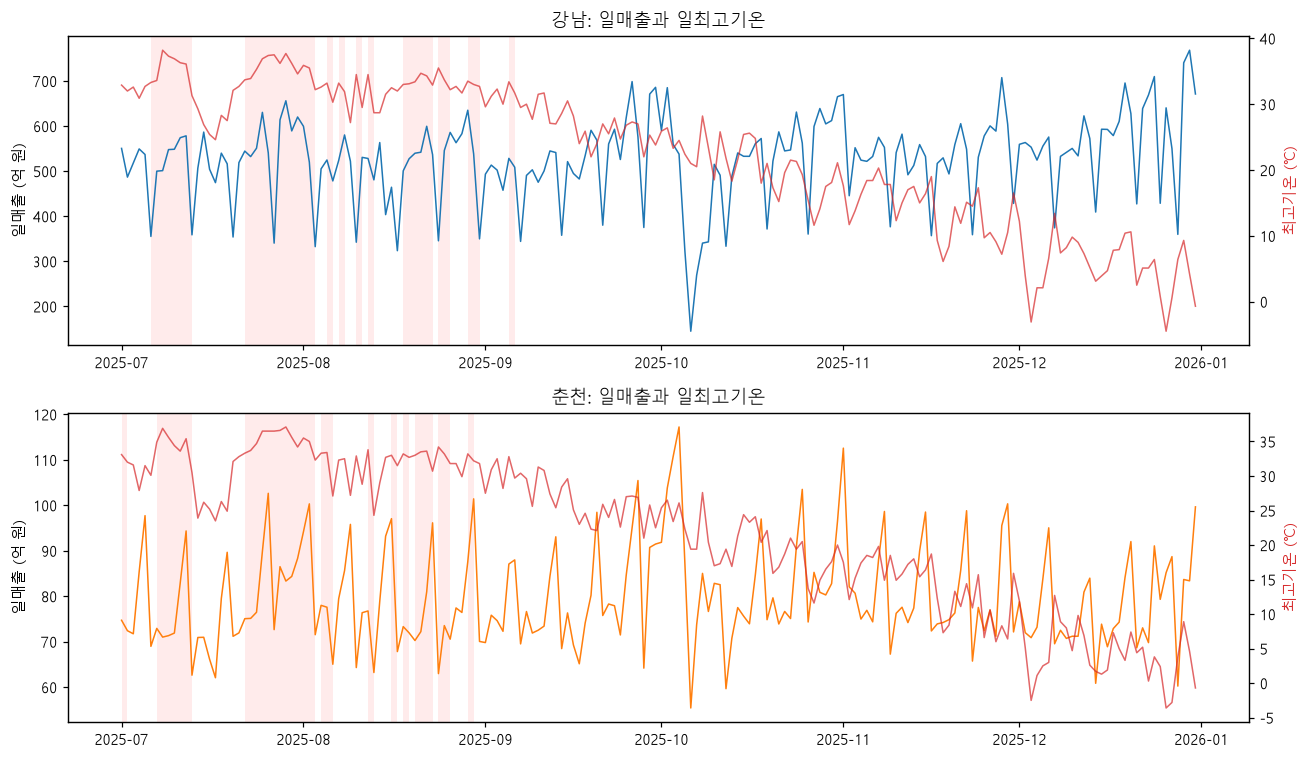

,전체 상관,7~9월 상관
region,,
강남,-0.210,-0.020
춘천,0.030,0.120


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
for ax, r in zip(axes, REGIONS):
    g = daily[daily['region'].eq(r)]
    ax.plot(g['date'], g['amt'], color=REGION_COLOR[r], lw=1)
    ax.set(ylabel='일매출 (억 원)', title=f'{r}: 일매출과 일최고기온')
    ax2 = ax.twinx()
    ax2.plot(g['date'], g['tmax'], color=TEMP_COLOR, lw=1, alpha=0.7)
    ax2.set_ylabel('최고기온 (℃)', color=TEMP_COLOR)
    for d in g.loc[g['heat33'], 'date']:
        ax.axvspan(d, d + pd.Timedelta(days=1), color='red', alpha=0.08, lw=0)
plt.tight_layout(); plt.show()

행 = []
for r in REGIONS:
    g = daily[daily['region'].eq(r)]
    행.append({'region': r, '전체 상관': g['amt'].corr(g['tmax']),
               '7~9월 상관': g.loc[g['summer'], 'amt'].corr(g.loc[g['summer'], 'tmax'])})
display(pd.DataFrame(행).set_index('region').round(2))

### 1-2. 톱니(요일)가 흔들림의 얼마인가

In [8]:
행 = []
for r in REGIONS:
    g = daily[daily['region'].eq(r) & ~daily['is_holiday']]
    예측 = g.groupby('dow')['amt'].transform('mean')
    설명 = 1 - ((g['amt'] - 예측) ** 2).sum() / ((g['amt'] - g['amt'].mean()) ** 2).sum()
    d = daily[daily['region'].eq(r)]
    행.append({'region': r, '요일이 설명하는 비율': 설명,
               '8월 평균': d.loc[d['month'].eq(8), 'amt'].mean(),
               '나머지 달 평균': d.loc[~d['month'].eq(8), 'amt'].mean()})
표 = pd.DataFrame(행).set_index('region')
표['8월 / 나머지'] = 표['8월 평균'] / 표['나머지 달 평균']
display(표.round(2))

요일폭 = 요일평균.unstack('dow')
print('요일 차이(최대 - 최소, 억 원):', (요일폭.max(axis=1) - 요일폭.min(axis=1)).round(0).to_dict())
print('8월 눌림(억 원):', (표['나머지 달 평균'] - 표['8월 평균']).round(0).to_dict())

,요일이 설명하는 비율,8월 평균,나머지 달 평균,8월 / 나머지
region,,,,
강남,0.650,503.670,530.790,0.950
춘천,0.650,79.020,79.810,0.990


요일 차이(최대 - 최소, 억 원): {'강남': 234.0, '춘천': 29.0}
8월 눌림(억 원): {'강남': 27.0, '춘천': 1.0}


### 1-3. 여름 구간 확대해서 보기

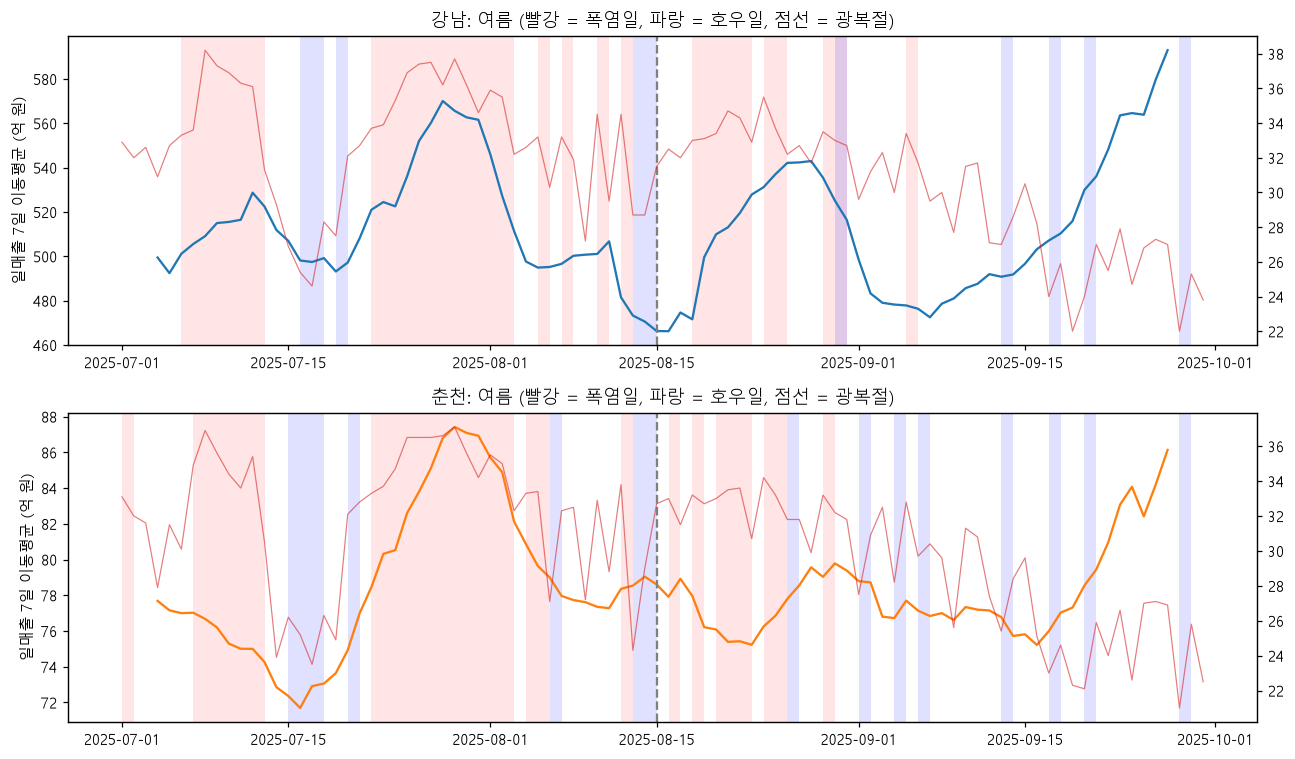

강남: 7일 이동평균이 가장 낮은 날 2025-08-16 | 폭염일 평균 532.2억 vs 비폭염일 507.0억
춘천: 7일 이동평균이 가장 낮은 날 2025-07-16 | 폭염일 평균 80.6억 vs 비폭염일 77.8억


In [9]:
여름구간 = daily[daily['date'].between('2025-07-01', '2025-09-30')]
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
for ax, r in zip(axes, REGIONS):
    g = 여름구간[여름구간['region'].eq(r)]
    ax.plot(g['date'], g['amt'].rolling(7, center=True).mean(), color=REGION_COLOR[r], lw=1.5)
    ax.axvline(pd.Timestamp('2025-08-15'), ls='--', color='gray')
    for d in g.loc[g['heat33'], 'date']:
        ax.axvspan(d, d + pd.Timedelta(days=1), color='red', alpha=0.10, lw=0)
    for d in g.loc[g['rain30'], 'date']:
        ax.axvspan(d, d + pd.Timedelta(days=1), color='blue', alpha=0.12, lw=0)
    ax.set(ylabel='일매출 7일 이동평균 (억 원)', title=f'{r}: 여름 (빨강 = 폭염일, 파랑 = 호우일, 점선 = 광복절)')
    ax2 = ax.twinx(); ax2.plot(g['date'], g['tmax'], color=TEMP_COLOR, lw=0.8, alpha=0.6)
plt.tight_layout(); plt.show()

for r in REGIONS:
    g = 여름구간[여름구간['region'].eq(r)]
    낮은날 = g.assign(ma=g['amt'].rolling(7, center=True).mean()).nsmallest(1, 'ma')
    print(f"{r}: 7일 이동평균이 가장 낮은 날 {낮은날['date'].iat[0].date()} | "
          f"폭염일 평균 {g.loc[g['heat33'], 'amt'].mean():.1f}억 vs 비폭염일 {g.loc[~g['heat33'], 'amt'].mean():.1f}억")

**분기** (그림을 보고 하나 체크)
- [ ] 8월 더운 구간에서 매출선이 눌려 보인다 -> Q3으로 직행 (3장)
- [x] 안 보인다 -> Q2 (2장)

> [추론] 안 보일 가능성이 높다. 요일 진폭이 기상 효과보다 크다. (기획 문서)

실제로 보이지 않았다. 요일이 일매출 흔들림의 **65%** 를 설명하고, 요일 차이(강남 234억)가 8월 눌림(27억)의 **8배** 가 넘는다.

다음으로 갈 곳: **2장 (Q2)**

### Q1 정리
- **본 것**: 일매출과 최고기온 겹쳐 그리기(1-1), 요일이 설명하는 비율(1-2), 여름 구간 확대(1-3)
- **나온 것**:
  - 일매출과 tmax 상관은 전체 기간 강남 -0.21, 춘천 +0.03이고 **여름만 보면 -0.02, +0.12로 사실상 없다**
  - 강남의 -0.21은 더위가 아니라 12월(연말 매출) 때문이다
  - 요일이 흔들림의 **65%** 를 설명한다. 강남 일요일 366억 vs 금요일 600억
  - 여름 폭염일 평균이 오히려 더 높다(강남 532억 vs 507억, 춘천 80.6억 vs 77.8억)
- **시사점**: 아무 보정 없이 보면 **더위 효과는 보이지 않는다**. 가장 크게 눌린 구간은 더운 날이 아니라 연휴(강남 8/16 광복절)와 호우(춘천 7/16)였다

## 2. Q2 무엇에 가려져 있나
더위 효과를 가리는 것 두 가지를 차례로 걷어낸다.
- **2-a 요일**: 요일별 평균을 빼고(나누고) 다시 그린다. 공휴일과 추석은 따로 표시한다.
- **2-b 업종끼리의 상쇄**: 더울 때 오르는 업종과 내리는 업종이 합계 안에서 서로 지워질 수 있다. 업종별로 쪼개 본다.

### 2-1. (2-a) 요일 보정 매출 다시 그리기

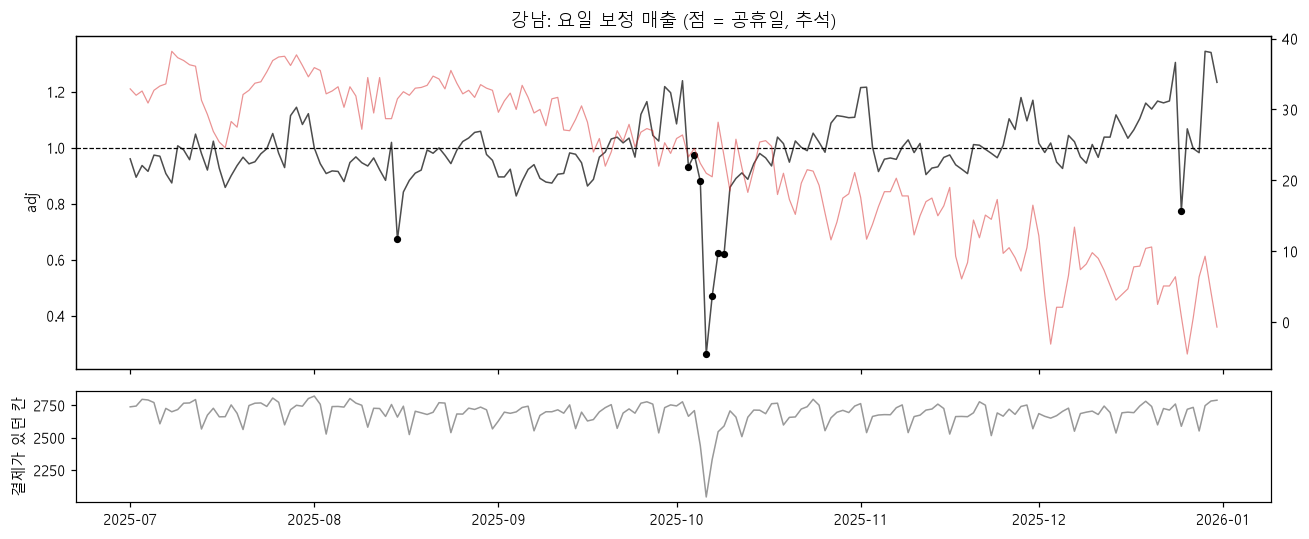

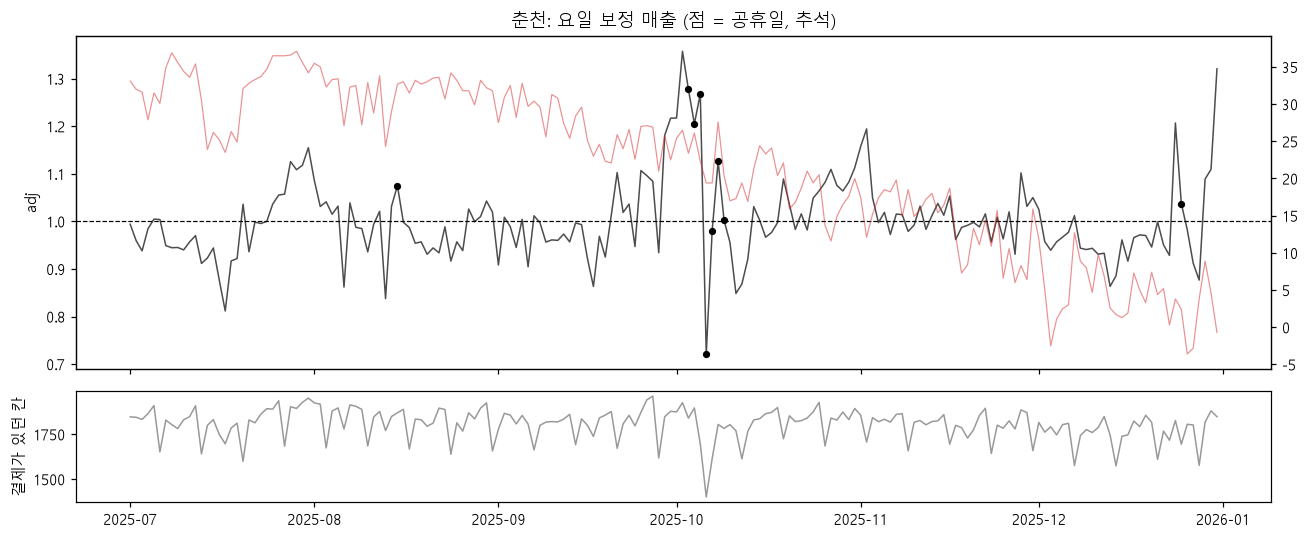

월별 adj 평균 (ok인 날)


month,7,8,9,10,11,12
region,,,,,,
강남,0.980,0.960,0.970,1.010,1.010,1.080
춘천,0.980,0.980,1.000,1.040,1.020,0.980


여름 월말 효과


,25일 전,25일 이후
region,,
강남,0.940,1.060
춘천,0.970,1.060


In [10]:
for r in REGIONS:
    g = daily[daily['region'].eq(r)]
    fig, ax1, ax2 = plot_with_rows(g, 'adj', title=f'{r}: 요일 보정 매출 (점 = 공휴일, 추석)', ylabel='adj')
    ax1.axhline(1, ls='--', color='k', lw=0.8)
    휴 = g[g['is_holiday'] | g['is_chuseok_break']]
    ax1.scatter(휴['date'], 휴['adj'], color='k', zorder=3, s=14)
    axt = ax1.twinx(); axt.plot(g['date'], g['tmax'], color=TEMP_COLOR, lw=0.8, alpha=0.5)
    plt.tight_layout(); plt.show()

print('월별 adj 평균 (ok인 날)')
display(daily[daily['ok']].pivot_table(index='region', columns='month', values='adj').round(2))

여름ok = daily[daily['summer'] & daily['ok']]
월말 = 여름ok.assign(월말=여름ok['date'].dt.day >= 25).groupby(['region', '월말'])['adj'].mean().unstack()
월말.columns = ['25일 전', '25일 이후']
print('여름 월말 효과'); display(월말.round(2))

### 2-2. 요일 보정 매출과 기온의 관계

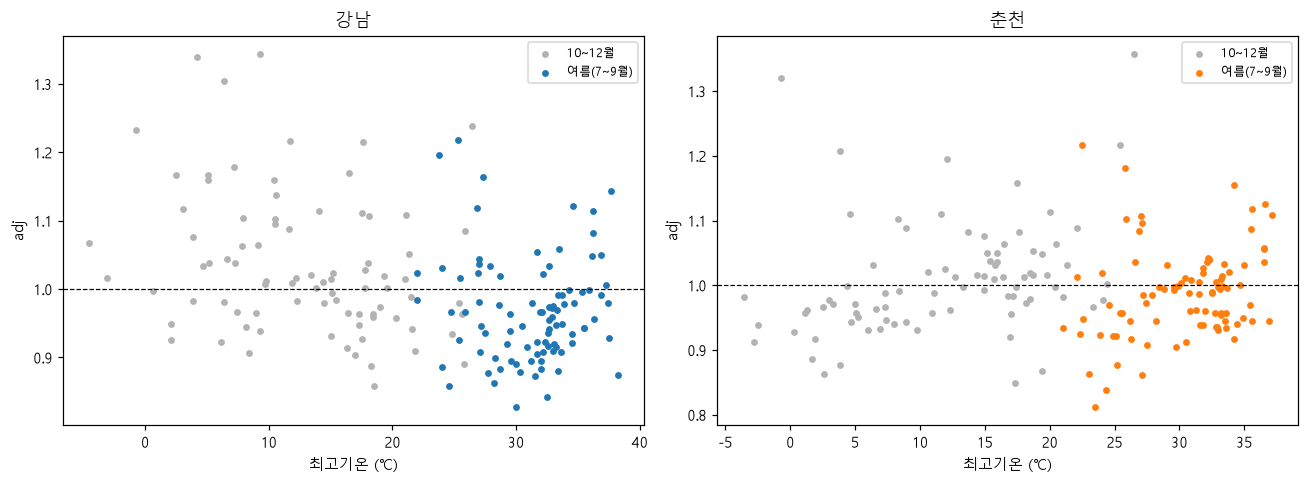

,전체 상관,여름 상관,여름 폭염일 adj,여름 비폭염일 adj
region,,,,
강남,-0.400,-0.040,0.980,0.960
춘천,0.040,0.240,1.010,0.980


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, r in zip(axes, REGIONS):
    g = daily[daily['region'].eq(r) & daily['ok']]
    ax.scatter(g.loc[~g['summer'], 'tmax'], g.loc[~g['summer'], 'adj'], s=12, color='0.7', label='10~12월')
    ax.scatter(g.loc[g['summer'], 'tmax'], g.loc[g['summer'], 'adj'], s=12,
               color=REGION_COLOR[r], label='여름(7~9월)')
    ax.axhline(1, ls='--', color='k', lw=0.8)
    ax.set(xlabel='최고기온 (℃)', ylabel='adj', title=f'{r}')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

행 = []
for r in REGIONS:
    g = daily[daily['region'].eq(r) & daily['ok']]
    s = g[g['summer']]
    행.append({'region': r, '전체 상관': g['tmax'].corr(g['adj']), '여름 상관': s['tmax'].corr(s['adj']),
               '여름 폭염일 adj': s.loc[s['heat33'], 'adj'].mean(),
               '여름 비폭염일 adj': s.loc[~s['heat33'], 'adj'].mean()})
display(pd.DataFrame(행).set_index('region').round(2))

### 2-3. 마스킹 확인: 더운 날, 비 온 날에 행 수가 줄었나

In [12]:
# 01번 3-2에서 0으로 채웠기 때문에 '칸이 사라지는' 현상은 더 이상 없다.
# 대신 '결제가 있던 칸 수(rows_paid)'가 더운 날, 비 온 날에 줄어드는지 본다.
행평균 = daily[~daily['is_holiday']].groupby(['region', 'dow'])['rows_paid'].mean().rename('rows_dow_mean')
daily = daily.merge(행평균, on=['region', 'dow'], how='left')
daily['rows_adj'] = daily['rows_paid'] / daily['rows_dow_mean']

행 = []
for r in REGIONS:
    g = daily[daily['region'].eq(r) & daily['summer'] & daily['ok']]
    h, w = effect(g, 'rows_adj')
    행.append({'region': r, '여름 하루 평균 칸 수': g['rows_paid'].mean(),
               '칸 수 폭염 효과': h, '칸 수 비 효과': w,
               'rows_adj와 adj 상관': g['rows_adj'].corr(g['adj'])})
display(pd.DataFrame(행).set_index('region').round(2))
print('※ 01번에서 0으로 채운 뒤라 전체 행 수(rows)는 날마다 거의 같다. 여기서 보는 것은 "결제가 있던 칸"의 수다.')

,여름 하루 평균 칸 수,칸 수 폭염 효과,칸 수 비 효과,rows_adj와 adj 상관
region,,,,
강남,"2,705.000",1.010,0.980,0.430
춘천,"1,821.700",1.000,0.970,0.770


※ 01번에서 0으로 채운 뒤라 전체 행 수(rows)는 날마다 거의 같다. 여기서 보는 것은 "결제가 있던 칸"의 수다.


### 2-4. (2-b) 업종 고르기: 상위 15개와 야외성 업종

In [13]:
OUTDOOR = ['실내/실외골프장', '종합레저타운/놀이동산', '스포츠시설', '주유소', '호텔/콘도',
           '모텔,여관,기타숙박', '영화/공연', '커피전문점', '편의점']

SEL_IND = {}
for r in REGIONS:
    g = base1[base1['region'].eq(r)]
    상위 = g.groupby('industry')['amount'].sum().nlargest(15).index.tolist()
    있는것 = set(g.loc[g['amount'] > 0, 'industry'])
    추가 = [i for i in OUTDOOR if i in 있는것 and i not in 상위]
    SEL_IND[r] = 상위 + 추가
    print(f'{r} 상위 15: {상위}')
    print(f'   + 야외성 추가: {추가}  -> 모두 {len(SEL_IND[r])}개')

강남 상위 15: ['일반병원', '할인점/슈퍼마켓/양판점', '쇼핑몰', '한식', '기타의료', '백화점', '의복/의류', '종합병원', '기타요식', '커피전문점', '편의점', '치과병원', '약국', '미용실', '양식']
   + 야외성 추가: ['실내/실외골프장', '스포츠시설', '주유소', '호텔/콘도', '모텔,여관,기타숙박', '영화/공연']  -> 모두 21개
춘천 상위 15: ['할인점/슈퍼마켓/양판점', '한식', '주유소', '기타요식', '편의점', '일반병원', '기타식품', '실내/실외골프장', '약국', '종합병원', '치과병원', '스포츠/레저용품', '자동차서비스', '자동차용품', '정육점']
   + 야외성 추가: ['종합레저타운/놀이동산', '스포츠시설', '호텔/콘도', '모텔,여관,기타숙박', '영화/공연', '커피전문점']  -> 모두 21개


### 2-5. 업종별 작은 격자 그리기

daily_ind (24462, 24)


강남: 상위 15개 중 + 7개 / - 8개
   +큰쪽 [('주유소', 0.53), ('할인점/슈퍼마켓/양판점', 0.31), ('스포츠시설', 0.3)] | -큰쪽 [('양식', -0.33), ('의복/의류', -0.29), ('백화점', -0.29)]
춘천: 상위 15개 중 + 7개 / - 8개
   +큰쪽 [('커피전문점', 0.66), ('스포츠시설', 0.58), ('주유소', 0.55)] | -큰쪽 [('자동차용품', -0.2), ('정육점', -0.16), ('약국', -0.16)]


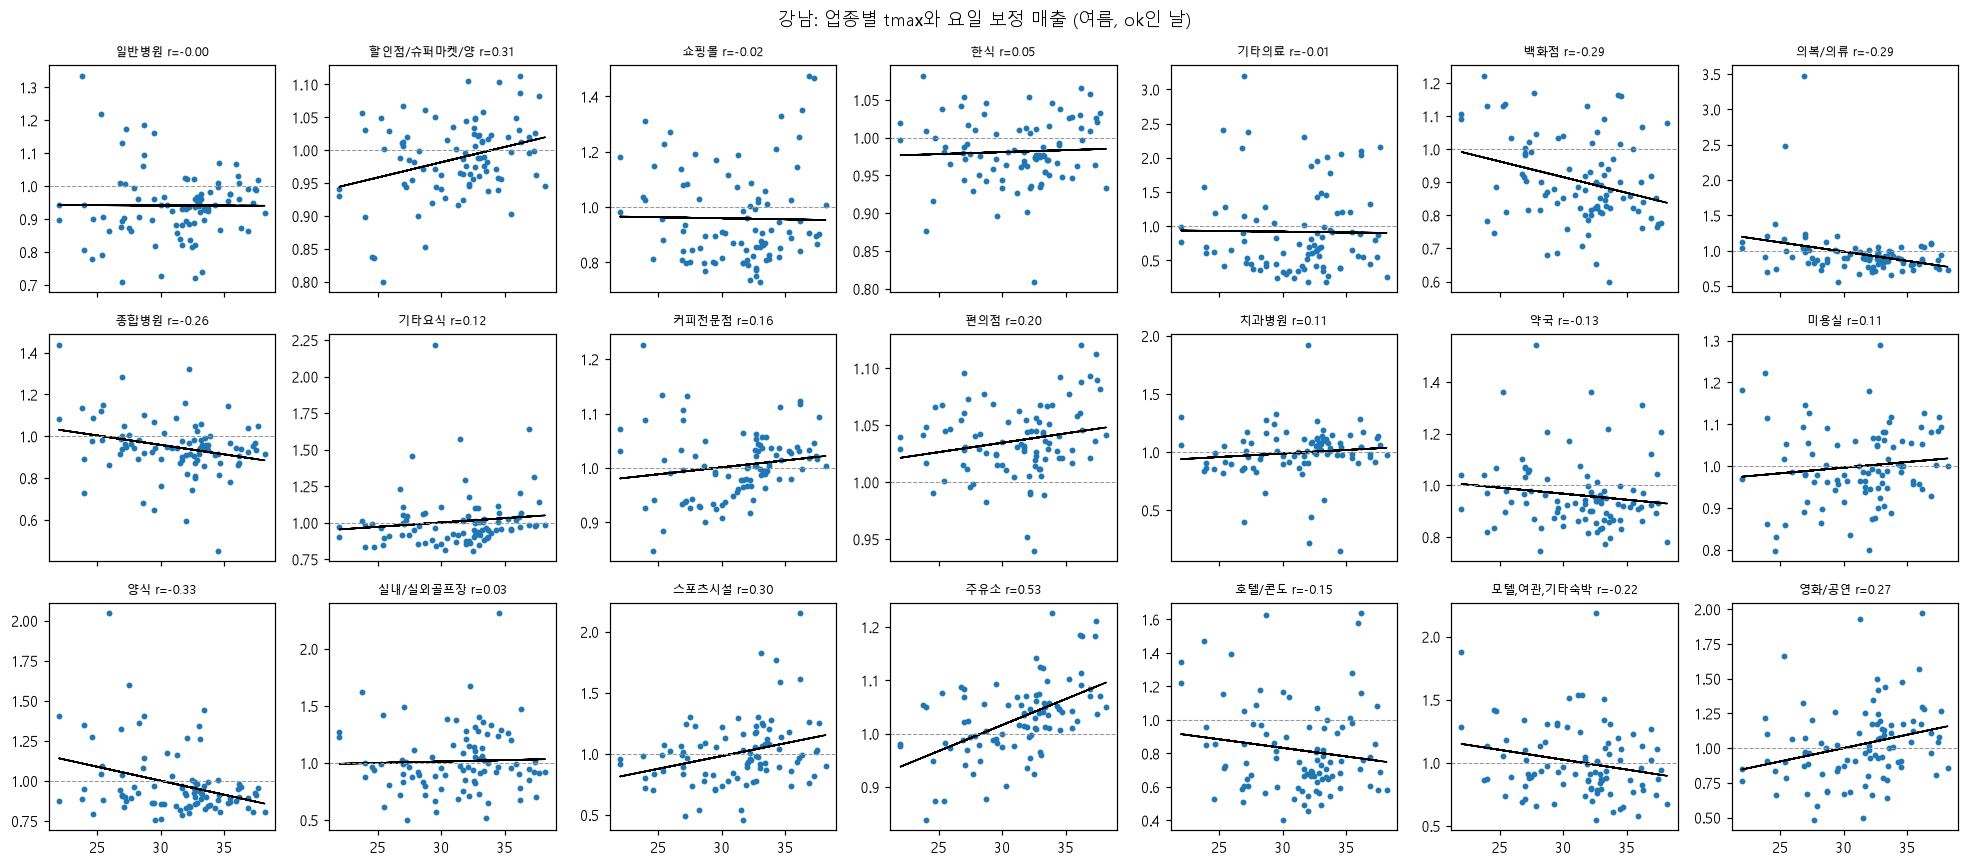

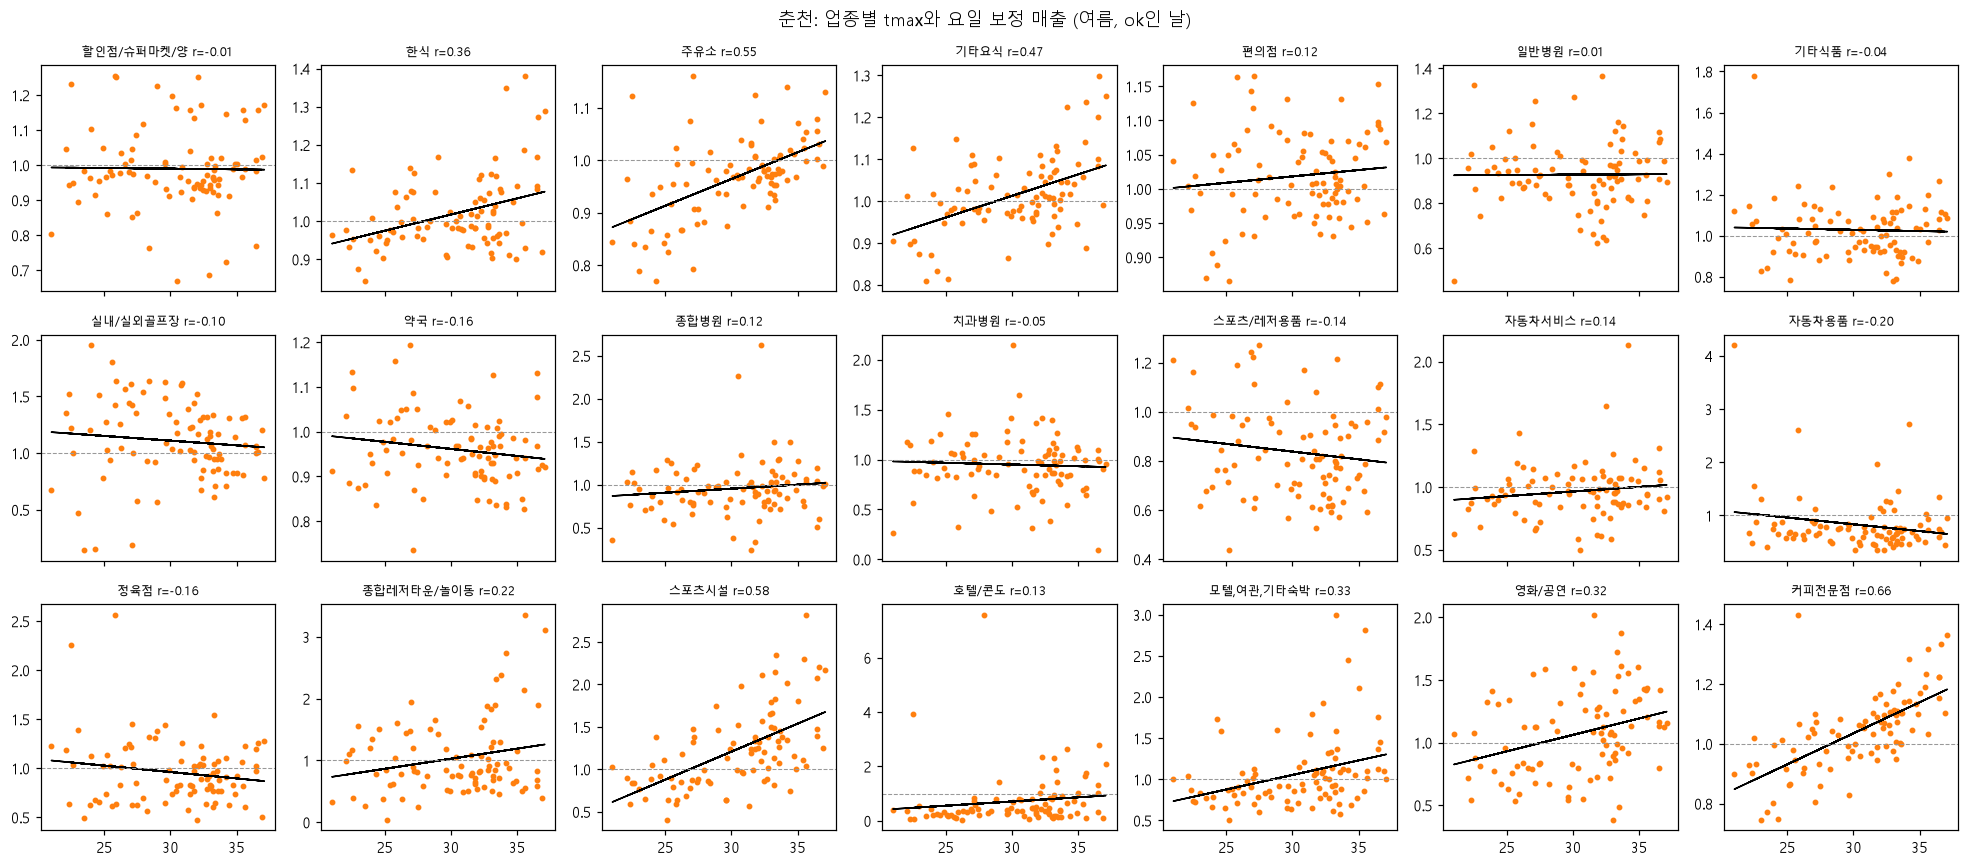

In [14]:
daily_ind = (base1.groupby(['region', 'industry', 'date'], as_index=False)
             .agg(amount=('amount', 'sum'), cnt=('cnt', 'sum')))
daily_ind = daily_ind.merge(calendar, on='date').merge(
    wx[['date', 'region', 'tmax', 'tmin', 'rain', 'heat33', 'rain30']], on=['date', 'region'])
daily_ind['ok'] = ~daily_ind['is_holiday'] & ~daily_ind['is_chuseok_break']
daily_ind['summer'] = daily_ind['month'].between(7, 9)
daily_ind['dry'] = daily_ind['rain'] < 1
daily_ind['wet'] = daily_ind['rain'] >= 5

평균 = (daily_ind[~daily_ind['is_holiday']]
        .groupby(['region', 'industry', 'dow'])['amount'].mean().rename('dow_mean'))
daily_ind = daily_ind.merge(평균, on=['region', 'industry', 'dow'], how='left')
daily_ind['adj'] = daily_ind['amount'] / daily_ind['dow_mean']
print('daily_ind', daily_ind.shape)

상관 = []
for r in REGIONS:
    for ind in SEL_IND[r]:
        g = daily_ind[(daily_ind['region'] == r) & (daily_ind['industry'] == ind)
                      & daily_ind['summer'] & daily_ind['ok']].dropna(subset=['adj'])
        if len(g) > 10:
            상관.append({'region': r, 'industry': ind, 'corr': g['tmax'].corr(g['adj'])})
상관표 = pd.DataFrame(상관)
for r in REGIONS:
    t = 상관표[상관표['region'].eq(r)].sort_values('corr')
    상위15 = t[t['industry'].isin(SEL_IND[r][:15])]
    print(f"{r}: 상위 15개 중 + {int((상위15['corr'] > 0).sum())}개 / - {int((상위15['corr'] < 0).sum())}개")
    print('   +큰쪽', [(x.industry, round(x.corr, 2)) for x in t.nlargest(3, 'corr').itertuples()],
          '| -큰쪽', [(x.industry, round(x.corr, 2)) for x in t.nsmallest(3, 'corr').itertuples()])

for r in REGIONS:
    목록 = SEL_IND[r][:21]
    fig, axes = plt.subplots(3, 7, figsize=(18, 8), sharex=True)
    for ax, ind in zip(axes.ravel(), 목록):
        g = daily_ind[(daily_ind['region'] == r) & (daily_ind['industry'] == ind)
                      & daily_ind['summer'] & daily_ind['ok']].dropna(subset=['adj'])
        ax.scatter(g['tmax'], g['adj'], s=8, color=REGION_COLOR[r])
        if len(g) > 2:
            k = np.polyfit(g['tmax'], g['adj'], 1)
            ax.plot(g['tmax'], np.poly1d(k)(g['tmax']), color='k', lw=1)
            ax.set_title(f"{ind[:10]} r={g['tmax'].corr(g['adj']):.2f}", fontsize=8)
        ax.axhline(1, ls='--', color='0.6', lw=0.7)
    for ax in axes.ravel()[len(목록):]:
        ax.axis('off')
    fig.suptitle(f'{r}: 업종별 tmax와 요일 보정 매출 (여름, ok인 날)')
    plt.tight_layout(); plt.show()

**분기** (하나 체크)
- [x] 업종별로 부호가 갈린다 -> Q3
- [ ] 전 업종이 같은 방향으로 미미하다 -> 기상 효과가 작다는 잠정 결론. Q4에서 강수를 확인한 뒤 판단
- [ ] 특정 업종만 크게 움직인다 -> 그 업종을 들고 Q3 (업종 이름: )

상위 15개 업종의 tmax 상관 부호가 두 지역 모두 **+7개 / -8개**로 갈렸다. 합계에서 서로 지워지고 있었다는 뜻이다.

다음으로 갈 곳: **3장 (Q3)**

### Q2 정리
- **본 것**: 요일 보정 매출 다시 그리기(2-1), 기온과의 관계(2-2), 결제가 있던 칸 수 확인(2-3), 업종별 격자(2-4, 2-5)
- **나온 것**:
  - 요일을 걷어내도 **더운 날 매출이 줄어드는 모습은 없다**(여름 상관 강남 -0.04, 춘천 +0.24)
  - **월말 효과가 크다.** 여름 25일 이후 adj가 1.06, 그 전이 강남 0.94 춘천 0.97로 10%p 넘게 차이 난다
  - 결제가 있던 칸 수는 더운 날 줄지 않고(1.01, 1.00) **비 온 날에만 2~3% 준다**(0.98, 0.97)
  - 업종별 tmax 상관은 강남 주유소 +0.53 ~ 양식 -0.33, 춘천 커피전문점 +0.66 ~ 자동차용품 -0.20으로 **부호가 갈린다**
- **시사점**:
  - 합계로는 0이지만 **업종 안에서는 반대 방향으로 움직이고 있었다.** 업종 단위로 봐야 한다
  - 월말 효과를 통제하지 않으면 폭염 구간이 월말과 겹칠 때 결과가 흔들린다(8-1에서 실제로 그렇다)
  - > [추론] +쪽 업종이 "더워서 잘 팔린" 것인지 "시원한 날이 비 온 날이라 덜 팔린" 것인지는 Q4 전까지 알 수 없다

## 3. Q3 기온과 매출의 관계가 어떤 모양인가
**임계값을 정하지 않고** 시작한다. x축 일최고기온, y축 요일 보정 매출. 구간 평균선에 **구간마다 관측 수**를 같이 찍어서 꼬리가 몇 개짜리인지 보이게 한다.
볼 것: 선형인가, 특정 기온에서 꺾이는가, U자인가. 꺾이는 지점이 업종마다 다른가. 33℃ 근처인가 아닌가.

> 명세서 04번의 33/35℃ 임계는 여기 결과가 나온 뒤에 확정한다. 기상청 기준과 데이터가 말하는 지점이 다르면 그 차이 자체가 결과이다. (기획 문서)

### 3-1. 지역 합계: 산점도와 1℃ 구간 평균

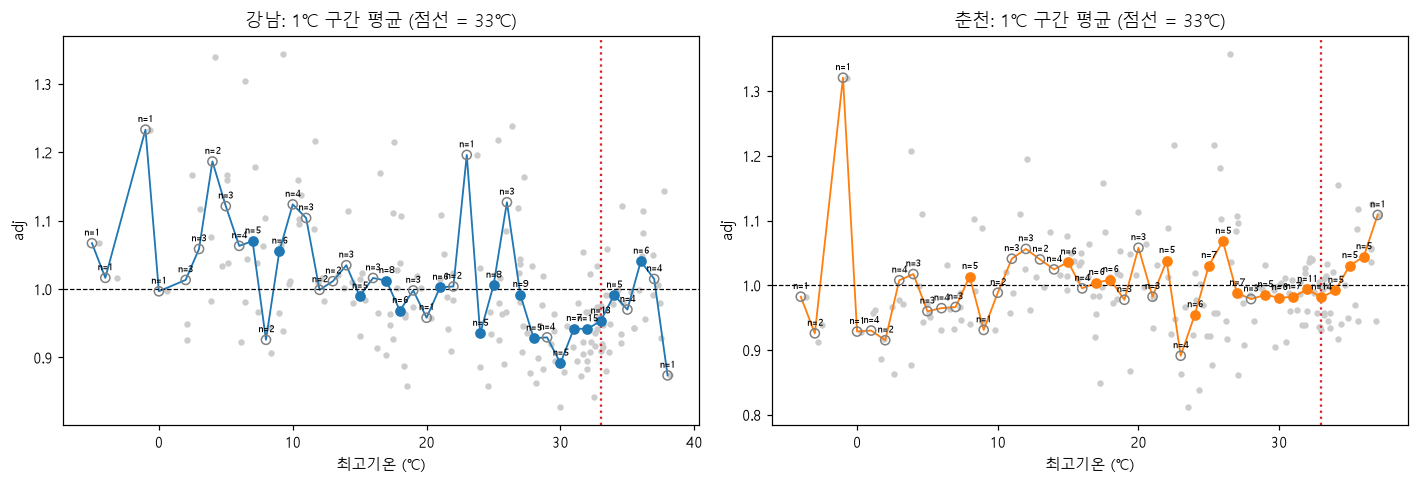

강남 (24℃ 이상)


tmax,24.000,25.000,26.000,27.000,28.000,29.000,30.000,31.000,32.000,33.000,34.000,35.000,36.000,37.000,38.000
mean,0.940,1.010,1.130,0.990,0.930,0.930,0.890,0.940,0.940,0.950,0.990,0.970,1.040,1.010,0.870
n,5,8,3,9,5,4,5,7,15,13,5,4,6,4,1
use,True,True,False,True,True,False,True,True,True,True,True,False,True,False,False


춘천 (24℃ 이상)


tmax,24.000,25.000,26.000,27.000,28.000,29.000,30.000,31.000,32.000,33.000,34.000,35.000,36.000,37.000
mean,0.950,1.030,1.070,0.990,0.980,0.990,0.980,0.980,0.990,0.980,0.990,1.030,1.040,1.110
n,6,7,5,7,3,5,6,7,11,14,5,5,5,1
use,True,True,True,True,False,True,True,True,True,True,True,True,True,False


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, r in zip(axes, REGIONS):
    g = daily[daily['region'].eq(r) & daily['ok']]
    ax.scatter(g['tmax'], g['adj'], s=10, color='0.8')
    b = binned_mean(g, 'tmax', 'adj', width=1)
    ax.plot(b.index, b['mean'], color=REGION_COLOR[r], lw=1.2)
    ax.scatter(b.index[b['use']], b.loc[b['use'], 'mean'], color=REGION_COLOR[r], zorder=3)
    ax.scatter(b.index[~b['use']], b.loc[~b['use'], 'mean'], facecolors='none', edgecolors='0.5', zorder=3)
    for x, row in b.iterrows():
        ax.annotate(f"n={int(row['n'])}", (x, row['mean']), textcoords='offset points',
                    xytext=(0, 5), ha='center', fontsize=6)
    ax.axhline(1, ls='--', color='k', lw=0.8)
    ax.axvline(THRESH['heat33'], ls=':', color=TEMP_COLOR)
    ax.set(xlabel='최고기온 (℃)', ylabel='adj', title=f'{r}: 1℃ 구간 평균 (점선 = 33℃)')
plt.tight_layout(); plt.show()

for r in REGIONS:
    b = binned_mean(daily[daily['region'].eq(r) & daily['ok']], 'tmax', 'adj', width=1)
    print(f'{r} (24℃ 이상)')
    display(b[b.index >= 24].round(2).T)

### 3-2. 꺾이는 지점 찾기 (선택)

강남: 가장 잘 맞는 k = 30.5℃ (직선 RSS 0.534 -> 꺾은선 0.447), k 아래 기울기 -0.016/℃, k 위 +0.014/℃
춘천: 가장 잘 맞는 k = 34.5℃ (직선 RSS 0.427 -> 꺾은선 0.411), k 아래 기울기 +0.002/℃, k 위 +0.029/℃


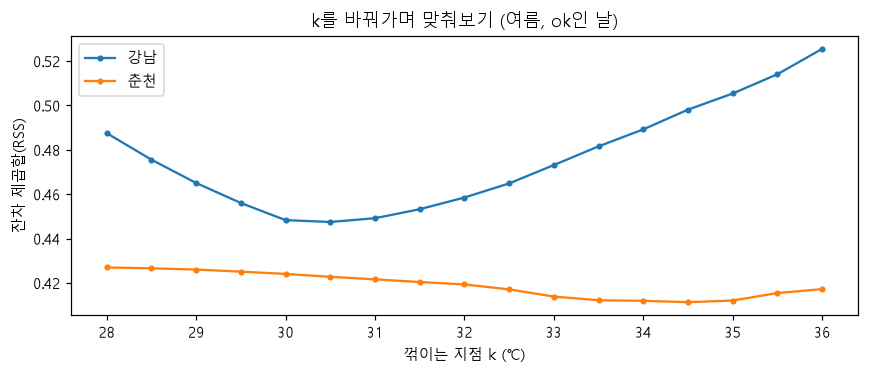

In [16]:
def 꺾은선(g, ks=np.arange(28, 36.5, 0.5)):
    """adj = a + b*tmax + c*max(tmax-k, 0) 을 k마다 맞춰 잔차 제곱합(RSS)을 돌려준다."""
    x, y = g['tmax'].values, g['adj'].values
    직선 = np.column_stack([np.ones(len(x)), x])
    rss0 = np.linalg.lstsq(직선, y, rcond=None)[1][0]
    행 = []
    for k in ks:
        X = np.column_stack([np.ones(len(x)), x, np.maximum(x - k, 0)])
        beta, rss, *_ = np.linalg.lstsq(X, y, rcond=None)
        행.append({'k': k, 'RSS': rss[0] if len(rss) else np.nan,
                   'k 아래 기울기': beta[1], 'k 위 기울기': beta[1] + beta[2]})
    return rss0, pd.DataFrame(행)


fig, ax = plt.subplots(figsize=(8, 3.5))
for r in REGIONS:
    g = daily[daily['region'].eq(r) & daily['summer'] & daily['ok']]
    rss0, t = 꺾은선(g)
    최적 = t.loc[t['RSS'].idxmin()]
    ax.plot(t['k'], t['RSS'], marker='o', ms=3, color=REGION_COLOR[r], label=r)
    print(f"{r}: 가장 잘 맞는 k = {최적['k']}℃ (직선 RSS {rss0:.3f} -> 꺾은선 {최적['RSS']:.3f}), "
          f"k 아래 기울기 {최적['k 아래 기울기']:+.3f}/℃, k 위 {최적['k 위 기울기']:+.3f}/℃")
ax.set(xlabel='꺾이는 지점 k (℃)', ylabel='잔차 제곱합(RSS)', title='k를 바꿔가며 맞춰보기 (여름, ok인 날)')
ax.legend(); plt.tight_layout(); plt.show()

### 3-3. 업종별 구간 평균

In [17]:
비중 = base1.groupby(['region', 'industry'])['amount'].sum()
비중 = (비중 / 비중.groupby('region').sum()).rename('share')

행 = []
for (r, ind), g in daily_ind[daily_ind['summer'] & daily_ind['ok']].groupby(['region', 'industry']):
    if 비중.get((r, ind), 0) < 0.005:
        continue
    h, w = effect(g.dropna(subset=['adj']))
    행.append({'region': r, 'industry': ind, '폭염 효과': h, '비 효과': w, '금액 비중': 비중[(r, ind)]})
ind_eff = pd.DataFrame(행)

for r in REGIONS:
    t = ind_eff[ind_eff['region'].eq(r)]
    print(f'{r} 폭염 효과 낮은 5개'); display(t.nsmallest(5, '폭염 효과').set_index('industry')[['폭염 효과', '금액 비중']].round(3).T)
    print(f'{r} 폭염 효과 높은 3개'); display(t.nlargest(3, '폭염 효과').set_index('industry')[['폭염 효과']].round(3).T)

for r in REGIONS:
    g = daily[daily['region'].eq(r) & daily['summer'] & daily['ok']]
    print(f'{r} 지역 합계 폭염 효과 {effect(g)[0]:.2f}')

강남 폭염 효과 낮은 5개


industry,기타식품,스포츠/레저용품,의복/의류,기타의료,제과점
폭염 효과,0.875,0.895,0.934,0.939,0.945
금액 비중,0.007,0.013,0.042,0.056,0.006


강남 폭염 효과 높은 3개


industry,서점,호텔/콘도,패션잡화
폭염 효과,1.293,1.109,1.091


춘천 폭염 효과 낮은 5개


industry,실내/실외골프장,기타의료,유흥업소,정육점,치과병원
폭염 효과,0.757,0.850,0.877,0.892,0.899
금액 비중,0.033,0.008,0.006,0.013,0.022


춘천 폭염 효과 높은 3개


industry,종합레저타운/놀이동산,패션잡화,종합병원
폭염 효과,1.202,1.189,1.102


강남 지역 합계 폭염 효과 1.00
춘천 지역 합계 폭염 효과 1.00


### 3-4. 일최저기온(열대야)으로 한 번 더

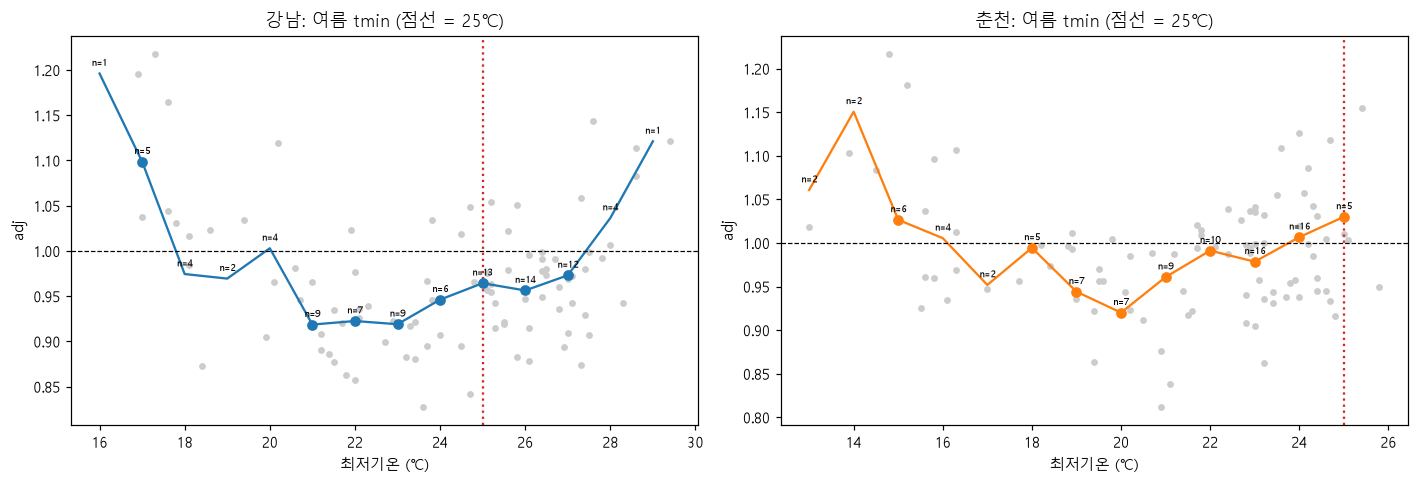

강남: 열대야 44일, adj 0.97 vs 아닌 날 0.96
춘천: 열대야 5일, adj 1.03 vs 아닌 날 0.99


강남 시간대별 열대야 효과


time_gb,00_05,06_11,12_17,18_23
adj,1.000,1.020,1.010,1.020


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, r in zip(axes, REGIONS):
    g = daily[daily['region'].eq(r) & daily['summer'] & daily['ok']]
    ax.scatter(g['tmin'], g['adj'], s=12, color='0.8')
    b = binned_mean(g, 'tmin', 'adj', width=1)
    ax.plot(b.index, b['mean'], color=REGION_COLOR[r])
    ax.scatter(b.index[b['use']], b.loc[b['use'], 'mean'], color=REGION_COLOR[r], zorder=3)
    for x, row in b.iterrows():
        ax.annotate(f"n={int(row['n'])}", (x, row['mean']), textcoords='offset points',
                    xytext=(0, 5), ha='center', fontsize=6)
    ax.axvline(THRESH['tropical'], ls=':', color=TEMP_COLOR)
    ax.axhline(1, ls='--', color='k', lw=0.8)
    ax.set(xlabel='최저기온 (℃)', ylabel='adj', title=f'{r}: 여름 tmin (점선 = 25℃)')
plt.tight_layout(); plt.show()

for r in REGIONS:
    g = daily[daily['region'].eq(r) & daily['summer'] & daily['ok']]
    print(f"{r}: 열대야 {int(g['tropical'].sum())}일, adj {g.loc[g['tropical'], 'adj'].mean():.2f} "
          f"vs 아닌 날 {g.loc[~g['tropical'], 'adj'].mean():.2f}")

# 강남 시간대별 열대야 효과 (시간대마다 요일 보정을 따로 한다)
slot = (T[T['region'].eq('강남')].groupby(['date', 'time_gb'], as_index=False)['amount'].sum()
        .merge(calendar, on='date').merge(wx[['date', 'region', 'tropical', 'rain']].query("region == '강남'"), on='date'))
slot['summer'] = slot['month'].between(7, 9)
slot['ok'] = ~slot['is_holiday'] & ~slot['is_chuseok_break']
m = slot[~slot['is_holiday']].groupby(['time_gb', 'dow'])['amount'].mean().rename('dow_mean')
slot = slot.merge(m, on=['time_gb', 'dow'], how='left')
slot['adj'] = slot['amount'] / slot['dow_mean']
s = slot[slot['summer'] & slot['ok']]
효과 = (s[s['tropical']].groupby('time_gb')['adj'].mean() / s[~s['tropical']].groupby('time_gb')['adj'].mean())
print('강남 시간대별 열대야 효과'); display(효과.round(2).to_frame().T)

**결정**: 폭염 임계값을 적어 둔다.

- **결정**: **33℃를 그대로 쓴다.** 다만 임계값 더미보다 **tmax를 연속 변수로** 넣는 쪽을 05번에서 같이 본다.
- **이유**: 데이터에는 33℃에서 꺾이는 모습이 없다. 꺾은선 회귀가 찾은 지점은 강남 30.5℃, 춘천 34.5℃로 서로 다르고,
  강남은 아래로 꺾이는 것이 아니라 **V자**(30.5℃ 아래 -0.016/℃, 위 +0.014/℃)다. 두 지역에 공통으로 쓸 데이터 기반 임계값이 없다.
  그렇다고 지역마다 다른 값을 쓰면 비교가 어려워지므로, **기상청 기준(33℃)을 유지하되 그 근거가 데이터가 아니라 관례임을 밝힌다.**

**분기** (하나 체크)
- [ ] 꺾이는 지점이 보인다 -> 그 값이 데이터가 말하는 임계값
- [x] 단조 선형 -> 임계값 대신 연속 변수로 다루는 편이 나음
- [ ] 모양이 안 잡힌다 -> 표본 부족. 업종그룹 단위로 묶어 재시도

정확히는 단조도 아니다. 강남은 V자, 춘천은 거의 평평하다. 어느 쪽도 **"33℃를 넘으면 줄어든다"는 모양이 아니다.**

다음으로 갈 곳: **4장 (Q4)**

### Q3 정리
- **본 것**: 1℃ 구간 평균(3-1), 꺾은선 회귀(3-2), 업종별 폭염 효과(3-3), 최저기온으로 다시(3-4)
- **나온 것**:
  - **33℃에서 꺾이는 모습이 두 지역 모두 없다.** 강남은 28~33℃가 가장 낮고 36℃ 이상에서 다시 올라가는 V자
  - 꺾은선 회귀: 강남 k=30.5℃(RSS 0.534 → 0.447), 춘천 k=34.5℃(0.427 → 0.411, 개선 작음)
  - 업종별로는 크게 갈린다. 춘천 실내/실외골프장 **0.76**, 기타의료 0.85 / 강남 기타식품 **0.88**, 스포츠/레저용품 0.90
  - 반대로 오르는 업종도 있다(강남 서점 1.29, 춘천 종합레저타운 1.20)
  - 열대야는 강남 44일인데 adj 0.97 vs 0.96으로 차이가 없고, **시간대별로도 밤 매출이 줄지 않는다**(18_23 1.02)
- **시사점**:
  - 합계와 임계값으로는 폭염 효과를 잡을 수 없다. **업종 단위로만 말할 수 있다**
  - 열대야는 라벨로서 쓸모가 낮다. 춘천은 5일뿐이라 두 지역 비교도 불가능하다

## 4. Q4 기온인가 비인가
폭염일은 대개 맑고 호우일은 흐리다. 그래서 "더운 날"과 "비 안 온 날"이 겹치고, "시원한 날"과 "비 온 날"이 겹친다. 둘을 분리해야 한다.

### 4-1. (4-a) 강수량 구간별 매출

전체 기간


mean                               n                           
rain_bin     0   0~5  5~20 20~50   50+       0    0~5   5~20  20~50   50+
region                                                                   
강남       1.010 0.980 0.970 0.940 0.910 123.000 22.000 17.000 10.000 3.000
춘천       1.020 1.000 0.950 0.930 0.910 117.000 22.000 17.000 12.000 7.000

여름만


mean                              n                          
rain_bin     0   0~5  5~20 20~50   50+      0    0~5   5~20 20~50   50+
region                                                                 
강남       0.980 0.950 0.930 0.960 0.910 56.000 14.000 10.000 8.000 3.000
춘천       1.010 0.990 0.960 0.940 0.910 57.000  8.000 10.000 9.000 7.000

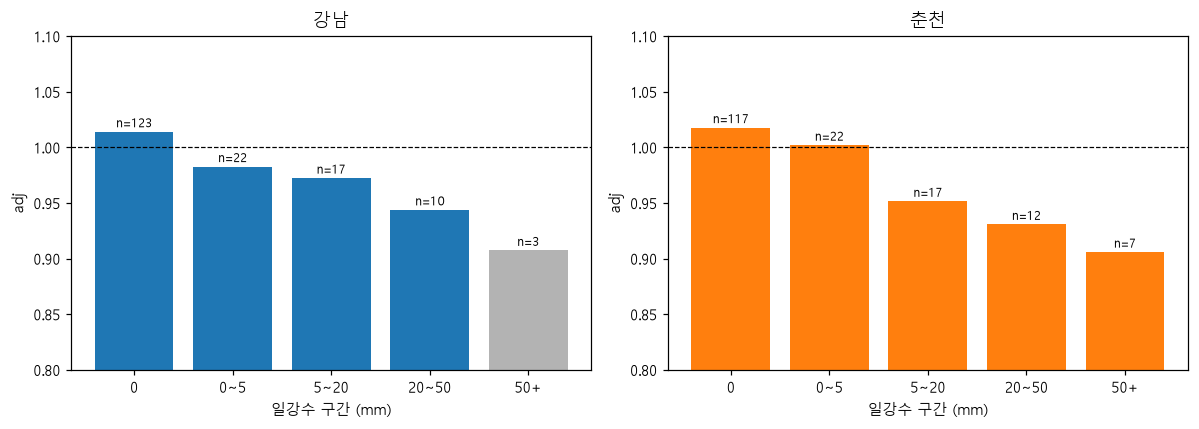

In [19]:
구간 = pd.cut(daily['rain'], [-0.1, 0, 5, 20, 50, 1000], labels=['0', '0~5', '5~20', '20~50', '50+'])
daily['rain_bin'] = 구간

for 라벨, 조건 in [('전체 기간', daily['ok']), ('여름만', daily['ok'] & daily['summer'])]:
    t = (daily[조건].groupby(['region', 'rain_bin'], observed=True)['adj']
         .agg(mean='mean', n='size').reset_index())
    print(라벨); display(t.pivot(index='region', columns='rain_bin', values=['mean', 'n']).round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, r in zip(axes, REGIONS):
    t = daily[daily['ok'] & daily['region'].eq(r)].groupby('rain_bin', observed=True)['adj'].agg(['mean', 'size'])
    색 = ['0.7' if n < 5 else REGION_COLOR[r] for n in t['size']]
    ax.bar(t.index.astype(str), t['mean'], color=색)
    for i, (m, n) in enumerate(zip(t['mean'], t['size'])):
        ax.annotate(f'n={n}', (i, m), textcoords='offset points', xytext=(0, 3), ha='center', fontsize=8)
    ax.axhline(1, ls='--', color='k', lw=0.8)
    ax.set(xlabel='일강수 구간 (mm)', ylabel='adj', title=f'{r}', ylim=(0.8, 1.1))
plt.tight_layout(); plt.show()

### 4-2. (4-b) 기온 × 강수 격자

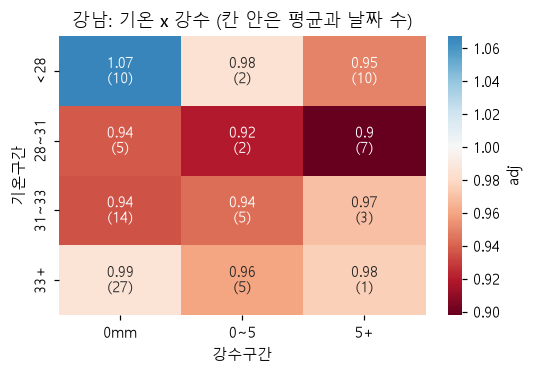

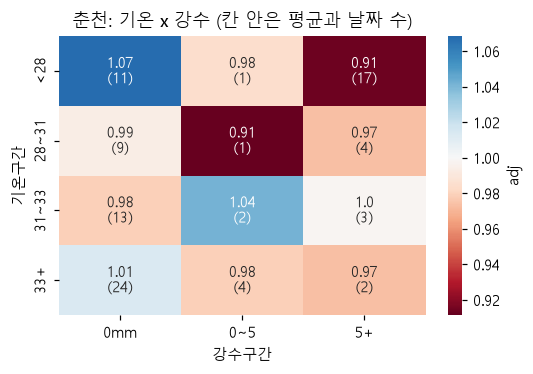

강남: 여름 tmax와 rain 상관 -0.46 | 폭염일 33일 중 비 온 날 6일
춘천: 여름 tmax와 rain 상관 -0.44 | 폭염일 30일 중 비 온 날 6일


In [20]:
여름ok = daily[daily['summer'] & daily['ok']].copy()
여름ok['기온구간'] = pd.cut(여름ok['tmax'], [0, 28, 31, 33, 50], right=False, labels=['<28', '28~31', '31~33', '33+'])
여름ok['강수구간'] = pd.cut(여름ok['rain'], [-0.1, 0, 5, 1000], labels=['0mm', '0~5', '5+'])

for r in REGIONS:
    g = 여름ok[여름ok['region'].eq(r)]
    평균 = g.pivot_table(index='기온구간', columns='강수구간', values='adj', aggfunc='mean', observed=True)
    개수 = g.pivot_table(index='기온구간', columns='강수구간', values='adj', aggfunc='size', observed=True)
    글자 = 평균.round(2).astype(str) + '\n(' + 개수.fillna(0).astype(int).astype(str) + ')'
    fig, ax = plt.subplots(figsize=(5, 3.5))
    sns.heatmap(평균, annot=글자, fmt='', cmap='RdBu', center=1, ax=ax, cbar_kws={'label': 'adj'})
    ax.set_title(f'{r}: 기온 x 강수 (칸 안은 평균과 날짜 수)')
    plt.tight_layout(); plt.show()

for r in REGIONS:
    g = 여름ok[여름ok['region'].eq(r)]
    폭염 = daily[daily['region'].eq(r) & daily['heat33']]
    print(f"{r}: 여름 tmax와 rain 상관 {g['tmax'].corr(g['rain']):.2f} | "
          f"폭염일 {len(폭염)}일 중 비 온 날 {int((폭염['rain'] > 0).sum())}일")

### 4-3. 두 효과 크기 나란히

In [21]:
행 = []
for r in REGIONS:
    g = daily[daily['region'].eq(r) & daily['summer'] & daily['ok']]
    h, w = effect(g)
    행.append({'region': r, '폭염 효과': h, '비 효과': w})
display(pd.DataFrame(행).set_index('region').round(3))

# 업종그룹별
grp = (base1.groupby(['region', 'industry_group', 'date'], as_index=False)['amount'].sum()
       .merge(calendar, on='date').merge(wx[['date', 'region', 'rain', 'heat33']], on=['date', 'region']))
grp['ok'] = ~grp['is_holiday'] & ~grp['is_chuseok_break']
grp['summer'] = grp['month'].between(7, 9)
grp['dry'], grp['wet'] = grp['rain'] < 1, grp['rain'] >= 5
m = grp[~grp['is_holiday']].groupby(['region', 'industry_group', 'dow'])['amount'].mean().rename('dow_mean')
grp = grp.merge(m, on=['region', 'industry_group', 'dow'], how='left')
grp['adj'] = grp['amount'] / grp['dow_mean']

행 = []
for (r, ig), g in grp[grp['summer'] & grp['ok']].groupby(['region', 'industry_group']):
    h, w = effect(g.dropna(subset=['adj']))
    행.append({'region': r, 'industry_group': ig, '폭염 효과': h, '비 효과': w})
grp_eff = pd.DataFrame(행)
display(grp_eff.pivot(index='industry_group', columns='region', values=['폭염 효과', '비 효과']).round(2))

print('\n회귀 (여름, ok인 날): adj ~ tmax + wet')
for r in REGIONS:
    g = daily[daily['region'].eq(r) & daily['summer'] & daily['ok']].assign(wet=lambda d: d['wet'].astype(int))
    fit = smf.ols('adj ~ tmax + wet', data=g).fit()
    print(f"  {r}: tmax {fit.params['tmax']:+.4f}/℃, 비 온 날 {fit.params['wet']:+.3f}, R² {fit.rsquared:.2f}")
print('※ 달(月)을 통제하지 않은 단순 비교다. 05번 3-2에서 월과 추석까지 통제한 결과와 다를 수 있다.')

,폭염 효과,비 효과
region,,
강남,1.003,0.956
춘천,0.999,0.929


폭염 효과        비 효과      
region            강남    춘천    강남    춘천
industry_group                        
교통/차량          1.000 0.990 0.960 0.890
대형유통           1.020 1.000 0.970 0.770
미용/생활서비스       1.010 1.010 0.940 0.960
생활/취미용품        1.020 1.010 0.900 0.860
숙박/여행          1.060 1.320 1.090 0.760
스포츠시설          1.070 0.840 0.970 0.810
식료품            1.000 0.980 0.930 0.980
여가/오락          1.070 1.060 0.920 0.880
음식점            1.000 1.050 0.970 0.930
의료             1.000 0.990 0.950 0.940
주점/유흥          0.960 0.880 1.000 1.000
카페             1.010 1.080 0.940 0.830
패션/뷰티          0.970 1.080 1.040 0.820
편의점            1.020 0.990 0.980 0.940


회귀 (여름, ok인 날): adj ~ tmax + wet
  강남: tmax -0.0040/℃, 비 온 날 -0.059, R² 0.08
  춘천: tmax -0.0004/℃, 비 온 날 -0.074, R² 0.22
※ 달(月)을 통제하지 않은 단순 비교다. 05번 3-2에서 월과 추석까지 통제한 결과와 다를 수 있다.


**결정**: 주제의 무게중심을 적어 둔다.

- **결정**: **호우를 앞에 두고 폭염은 업종 단위로만** 다룬다. 다만 강남 비 효과는 05번에서 월을 통제한 뒤 다시 판단한다.
- **이유**: 이 기간에 합계를 움직인 것은 비다(강남 0.96, 춘천 0.93). 폭염은 합계에서 1.00으로 흔적이 없고 업종 안에서만 보인다.
  강수는 "오느냐"보다 **"얼마나 오느냐"** 가 중요했다(0mm 1.01 → 50mm+ 0.91로 계단).

**분기** (하나 체크)
- [x] 강수 효과가 기온보다 크다 -> 주제 무게중심이 폭염에서 호우로 이동. 교수님과 상의할 사항
- [ ] 둘 다 있고 독립적 -> Q5부터 두 충격을 나란히

회귀로 동시에 봐도 비만 남는다(강남 비 -0.059, tmax -0.004/℃ / 춘천 비 -0.074, tmax -0.0004/℃).

다음으로 갈 곳: **5장 (Q5)**

### Q4 정리
- **본 것**: 강수 구간별 매출(4-1), 기온 x 강수 격자(4-2), 두 효과 나란히(4-3)
- **나온 것**:
  - 강수량이 많을수록 계단처럼 줄어든다. 0mm 1.01 / 0~5 0.98 / 5~20 0.97 / 20~50 0.94 / 50+ 0.91 (강남)
  - 여름 tmax와 rain 상관이 **-0.46, -0.44**라 "시원한 날"과 "비 온 날"이 상당히 겹친다
  - 폭염일 중 비 온 날은 두 지역 모두 6일뿐이라 **"더운데 비 온 날"은 비교할 수 없다**
  - 마른 날(0mm)만 놓고 보면 기온 구간별 차이가 작다 -> Q3에서 본 V자의 바닥은 비가 만든 것
  - 업종그룹 비 효과가 큰 쪽: 춘천 숙박/여행 0.76, 대형유통 0.77, 스포츠시설 0.81
- **시사점**:
  - **폭염 효과로 보였던 것의 상당 부분이 비 효과였다.** 마른 날끼리 비교해야 더위만의 효과가 남는다
  - > 주의: 여기 비 효과는 달을 통제하지 않은 단순 비교다. 05번에서 월과 추석까지 통제하면 **강남 호우 효과는 거의 사라질 수 있다**

## 5. Q5 누구의 매출이, 언제 줄었나
Q3, Q4에서 **가장 크게 반응한 업종 3~5개만** 골라 쪼갠다. 전 업종을 다 쪼개면 칸이 비어버린다.
순서: **시간대 -> 연령 -> 성별**. 시간대가 원인 해석에 가장 직접적이다.
볼 것: 낮 시간대(12~17)만 빠지는가 하루 종일인가. 열대야 다음 날 밤 시간대는. 고령층이 더 민감한가.

> 한 업종에서 나온 패턴을 다른 업종에 대입하지 않는다. (기획 문서)

**참고값의 기본 선택** (바꿔도 됨. 바꾸면 참고값과 달라짐)
- 강남: 의복/의류, 스포츠/레저용품, 기타식품 (3-3 폭염 효과 하위, 금액 비중 0.5% 이상. 기타의료는 원래 들쭉날쭉한 업종이라(02번 5-4 변동계수 1.08) 뺌)
- 춘천: 실내/실외골프장 (폭염, 비 모두 크게 반응), 종합레저타운/놀이동산, 커피전문점 (비 효과 하위)

### 5-1. 업종 고르기

In [22]:
for r in REGIONS:
    t = ind_eff[ind_eff['region'].eq(r)]
    print(f'{r} 비 효과 낮은 5개')
    display(t.nsmallest(5, '비 효과').set_index('industry')[['비 효과', '폭염 효과', '금액 비중']].round(3).T)

SEL = {'강남': ['의복/의류', '스포츠/레저용품', '기타식품'],
       '춘천': ['실내/실외골프장', '종합레저타운/놀이동산', '커피전문점']}
print('고른 업종:', SEL)

강남 비 효과 낮은 5개


industry,서점,기타의료,기타식품,기타요식,주유소
비 효과,0.688,0.777,0.830,0.898,0.925
폭염 효과,1.293,0.939,0.875,0.976,1.049
금액 비중,0.008,0.056,0.007,0.042,0.006


춘천 비 효과 낮은 5개


industry,종합레저타운/놀이동산,가전,기타유통,실내/실외골프장,패션잡화
비 효과,0.682,0.723,0.759,0.769,0.825
폭염 효과,1.202,1.028,1.016,0.757,1.189
금액 비중,0.006,0.008,0.005,0.033,0.006


고른 업종: {'강남': ['의복/의류', '스포츠/레저용품', '기타식품'], '춘천': ['실내/실외골프장', '종합레저타운/놀이동산', '커피전문점']}


### 5-2. 시간대별

In [23]:
def 축별효과(축):
    """고른 업종을 축(시간대, 연령, 성별)으로 쪼개 폭염 효과와 비 효과를 계산한다."""
    행 = []
    for r, inds in SEL.items():
        d = T[T['region'].eq(r) & T['industry'].isin(inds)]
        g = d.groupby(['industry', 축, 'date'], as_index=False)['amount'].sum()
        g = g.merge(calendar, on='date').merge(
            wx[['date', 'region', 'rain', 'heat33']].query('region == @r').drop(columns='region'), on='date')
        g['ok'] = ~g['is_holiday'] & ~g['is_chuseok_break']
        g['summer'] = g['month'].between(7, 9)
        g['dry'], g['wet'] = g['rain'] < 1, g['rain'] >= 5
        m = g[~g['is_holiday']].groupby(['industry', 축, 'dow'])['amount'].mean().rename('dow_mean')
        g = g.merge(m, on=['industry', 축, 'dow'], how='left')
        g['adj'] = g['amount'] / g['dow_mean']
        비중 = g.groupby(['industry', 축])['amount'].sum()
        비중 = (비중 / 비중.groupby('industry').sum() * 100).rename('비중(%)')
        for (ind, v), gg in g[g['summer'] & g['ok']].groupby(['industry', 축]):
            h, w = effect(gg.dropna(subset=['adj']))
            행.append({'region': r, 'industry': ind, 축: v, '폭염 효과': h, '비 효과': w,
                       '비중(%)': 비중[(ind, v)]})
    return pd.DataFrame(행)


slot_eff = 축별효과('time_gb')
for 지표 in ['폭염 효과', '비 효과']:
    print(f'{지표} (시간대별)')
    display(slot_eff.pivot_table(index=['region', 'industry'], columns='time_gb', values=지표).round(2))
print('시간대별 금액 비중(%)')
display(slot_eff.pivot_table(index=['region', 'industry'], columns='time_gb', values='비중(%)').round(1))

폭염 효과 (시간대별)


time_gb             00_05  06_11  12_17  18_23
region industry                               
강남     기타식품         0.810  0.880  0.860  0.940
       스포츠/레저용품     0.730  0.860  0.880  0.960
       의복/의류        0.640  0.760  0.950  0.990
춘천     실내/실외골프장     1.200  0.920  0.740  0.700
       종합레저타운/놀이동산    NaN  1.230  1.180  1.420
       커피전문점        0.790  1.100  1.090  1.040

비 효과 (시간대별)


time_gb             00_05  06_11  12_17  18_23
region industry                               
강남     기타식품         0.780  0.770  0.850  0.830
       스포츠/레저용품     1.230  1.110  0.960  0.900
       의복/의류        0.630  1.310  1.050  1.000
춘천     실내/실외골프장     0.630  0.820  0.760  0.750
       종합레저타운/놀이동산    NaN  0.800  0.690  0.490
       커피전문점        0.660  0.790  0.860  0.810

시간대별 금액 비중(%)


time_gb             00_05  06_11  12_17  18_23
region industry                               
강남     기타식품         0.800 21.000 58.700 19.600
       스포츠/레저용품     0.100 10.700 65.500 23.800
       의복/의류        0.100  9.000 69.700 21.300
춘천     실내/실외골프장     0.600 16.200 61.000 22.200
       종합레저타운/놀이동산  0.000 17.000 70.300 12.700
       커피전문점        0.100 18.200 62.200 19.600

### 5-3. 연령별

In [24]:
AGE_GROUP = {'10대': '10~20대', '20대': '10~20대', '30대': '30~40대', '40대': '30~40대',
             '50대': '50대', '60대': '60대 이상', '70대': '60대 이상', '80대': '60대 이상', '90대': '60대 이상'}
T['age_g'] = T['age'].map(AGE_GROUP)

age_eff = 축별효과('age_g')
for 지표 in ['폭염 효과', '비 효과']:
    print(f'{지표} (연령별)')
    display(age_eff.pivot_table(index=['region', 'industry'], columns='age_g', values=지표).round(2))

행 = []
for r in REGIONS:
    d = T[T['region'].eq(r)].groupby(['age_g', 'date'], as_index=False)['amount'].sum()
    d = d.merge(calendar, on='date').merge(
        wx[['date', 'region', 'rain', 'heat33']].query('region == @r').drop(columns='region'), on='date')
    d['ok'] = ~d['is_holiday'] & ~d['is_chuseok_break']; d['summer'] = d['month'].between(7, 9)
    d['dry'], d['wet'] = d['rain'] < 1, d['rain'] >= 5
    m = d[~d['is_holiday']].groupby(['age_g', 'dow'])['amount'].mean().rename('dow_mean')
    d = d.merge(m, on=['age_g', 'dow'], how='left'); d['adj'] = d['amount'] / d['dow_mean']
    for ag, g in d[d['summer'] & d['ok']].groupby('age_g'):
        h, w = effect(g.dropna(subset=['adj']))
        행.append({'region': r, 'age_g': ag, '폭염 효과': h, '비 효과': w})
print('지역 합계 연령별')
display(pd.DataFrame(행).pivot(index='age_g', columns='region', values=['폭염 효과', '비 효과']).round(2))

폭염 효과 (연령별)


age_g               10~20대  30~40대   50대  60대 이상
region industry                                 
강남     기타식품          0.910   0.840 0.860   0.960
       스포츠/레저용품      0.970   0.870 0.900   0.920
       의복/의류         0.930   0.940 0.880   0.980
춘천     실내/실외골프장      0.980   0.780 0.790   0.680
       종합레저타운/놀이동산   1.030   1.330 1.170   0.970
       커피전문점         1.040   1.090 1.110   1.070

비 효과 (연령별)


age_g               10~20대  30~40대   50대  60대 이상
region industry                                 
강남     기타식품          0.950   0.830 0.790   0.840
       스포츠/레저용품      0.930   0.950 1.010   1.010
       의복/의류         0.970   1.050 1.160   1.060
춘천     실내/실외골프장      0.790   0.790 0.740   0.770
       종합레저타운/놀이동산   0.780   0.660 0.630   0.820
       커피전문점         0.850   0.820 0.840   0.840

지역 합계 연령별


폭염 효과        비 효과      
region    강남    춘천    강남    춘천
age_g                         
10~20대 1.000 0.970 0.970 0.950
30~40대 1.010 1.030 0.960 0.930
50대    1.020 1.000 0.930 0.920
60대 이상 0.980 0.960 0.970 0.930

### 5-4. 성별

In [25]:
sex_eff = 축별효과('sex')
for 지표 in ['폭염 효과', '비 효과', '비중(%)']:
    print(지표)
    display(sex_eff.pivot_table(index=['region', 'industry'], columns='sex', values=지표).round(2))

폭염 효과


sex                   남성    여성
region industry               
강남     기타식품        0.850 0.890
       스포츠/레저용품    0.900 0.890
       의복/의류       1.000 0.910
춘천     실내/실외골프장    0.770 0.720
       종합레저타운/놀이동산 1.200 1.210
       커피전문점       1.070 1.090

비 효과


sex                   남성    여성
region industry               
강남     기타식품        0.800 0.860
       스포츠/레저용품    0.940 1.010
       의복/의류       1.040 1.090
춘천     실내/실외골프장    0.780 0.720
       종합레저타운/놀이동산 0.700 0.670
       커피전문점       0.860 0.810

비중(%)


sex                    남성     여성
region industry                 
강남     기타식품        45.420 54.580
       스포츠/레저용품    58.830 41.170
       의복/의류       37.760 62.240
춘천     실내/실외골프장    74.150 25.850
       종합레저타운/놀이동산 58.730 41.270
       커피전문점       48.120 51.880

### 5-5. 열대야 다음 날 밤 시간대

In [26]:
# 3-4에서 만든 강남 시간대 표(slot)를 다시 쓴다
s = slot[slot['summer'] & slot['ok']]
효과 = (s[s['tropical']].groupby('time_gb')['adj'].mean() / s[~s['tropical']].groupby('time_gb')['adj'].mean())
print('강남 합계, 시간대별 열대야 효과'); display(효과.round(2).to_frame().T)

# 열대야가 이틀 이상 이어진 날만
g = wx[wx['region'].eq('강남')].sort_values('date')
연속 = g['tropical'] & g['tropical'].shift(1)
연속날 = set(g.loc[연속, 'date'])
s2 = s[s['date'].isin(연속날)]
if len(s2):
    효과2 = (s2.groupby('time_gb')['adj'].mean() / s[~s['tropical']].groupby('time_gb')['adj'].mean())
    print(f'열대야가 이틀 이상 이어진 날({len(연속날)}일)만'); display(효과2.round(2).to_frame().T)
print('※ 춘천은 여름 열대야가 5일뿐이라 해석하지 않는다.')

강남 합계, 시간대별 열대야 효과


time_gb,00_05,06_11,12_17,18_23
adj,1.000,1.020,1.010,1.020


열대야가 이틀 이상 이어진 날(36일)만


time_gb,00_05,06_11,12_17,18_23
adj,1.000,1.010,1.010,1.030


※ 춘천은 여름 열대야가 5일뿐이라 해석하지 않는다.


**분기** (해당하는 것 모두 체크)
- [x] 낮 시간대(12~17)만 빠진다 -> 더위 노출(야외 이동)이 원인이라는 해석
- [ ] 하루 종일 빠진다 -> 외출 자체를 포기. Q6에서 건수로 확인
- [ ] 고령층이 더 민감하다 / [x] 아니다
- [x] 업종마다 패턴이 다르다 -> 업종별로 따로 보고 서로 대입하지 않음

다음으로 갈 곳: **6장 (Q6)**

### Q5 정리
- **본 것**: 업종 고르기(5-1), 시간대(5-2), 연령(5-3), 성별(5-4), 열대야 다음 날 밤(5-5)
- **나온 것**:
  - **폭염은 시간대마다 다르다.** 춘천 골프장은 12_17 0.74, 18_23 0.70으로 낮과 저녁 모두 빠지지만,
    강남 의복/의류는 06_11 0.76인데 18_23은 0.99로 **아침에만** 빠진다
  - **비는 하루 종일 빠진다.** 춘천 골프장 0.82 / 0.76 / 0.75, 커피전문점 0.79 / 0.86 / 0.81
  - 연령은 업종마다 다르다. 춘천 골프장은 60대 이상이 가장 크게 빠지지만(0.68) 강남 기타식품은 30~40대(0.84)가 더 크다
  - 성별 차이는 작다. 강남 의복/의류만 여성 0.91 vs 남성 1.00으로 갈린다
  - 열대야는 밤 시간대(18_23) 매출을 줄이지 않는다(1.02). 이틀 이상 이어진 날만 봐도 1.03
- **시사점**:
  - **"고령층이 더 민감하다"는 일반화는 성립하지 않는다.** 업종마다 방향이 다르다
  - 시간대 패턴이 업종마다 달라, 한 업종에서 본 모양을 다른 업종에 대입하면 안 된다

## 6. Q6 사람이 안 온 건가, 와서 덜 쓴 건가
매출 = 건수 × 객단가(한 건당 금액)이다. 어느 쪽이 줄었는지에 따라 해석이 달라진다.

| 관측 | 해석 |
|---|---|
| 건수 ↓ | 내점 자체가 차단 |
| 객단가 ↓ (건수 유지) | 나왔지만 덜 씀 |

지하철 승하차(사람 흐름)와 외지인 매출도 같이 본다.

### 6-1. (6-a) 건수와 객단가 나누기

In [27]:
daily['ticket'] = daily['amount'] / daily['cnt']
for col, 이름 in [('cnt', 'cnt_adj'), ('ticket', 'ticket_adj')]:
    m = daily[~daily['is_holiday']].groupby(['region', 'dow'])[col].mean().rename(f'{col}_dow')
    daily = daily.merge(m, on=['region', 'dow'], how='left')
    daily[이름] = daily[col] / daily[f'{col}_dow']

행 = []
for r in REGIONS:
    g = daily[daily['region'].eq(r) & daily['summer'] & daily['ok']]
    for 라벨, col in [('금액', 'adj'), ('건수', 'cnt_adj'), ('객단가', 'ticket_adj')]:
        h, w = effect(g, col)
        행.append({'region': r, '지표': 라벨, '폭염 효과': h, '비 효과': w})
print('지역 합계'); display(pd.DataFrame(행).pivot(index='지표', columns='region', values=['폭염 효과', '비 효과']).round(2))
print('객단가(원):', daily.groupby('region')['ticket'].mean().round(0).to_dict())

행 = []
for r, inds in SEL.items():
    for ind in inds:
        g = daily_ind[(daily_ind['region'] == r) & (daily_ind['industry'] == ind)
                      & daily_ind['summer'] & daily_ind['ok']].copy()
        g['ticket'] = g['amount'] / g['cnt']
        for col in ['cnt', 'ticket']:
            m = daily_ind[(daily_ind['region'] == r) & (daily_ind['industry'] == ind) & ~daily_ind['is_holiday']]
            if col == 'cnt':
                base = m.groupby('dow')['cnt'].mean()
                g['cnt_adj'] = g['cnt'] / g['dow'].map(base)
            else:
                base = (m['amount'] / m['cnt']).groupby(m['dow']).mean()
                g['ticket_adj'] = g['ticket'] / g['dow'].map(base)
        h, w = effect(g.dropna(subset=['adj']))
        hc, wc = effect(g.dropna(subset=['cnt_adj']), 'cnt_adj')
        ht, wt = effect(g.dropna(subset=['ticket_adj']), 'ticket_adj')
        행.append({'region': r, 'industry': ind, '폭염 금액': h, '폭염 건수': hc, '폭염 객단가': ht,
                   '비 금액': w, '비 건수': wc, '비 객단가': wt})
display(pd.DataFrame(행).set_index(['region', 'industry']).round(2))

지역 합계


폭염 효과        비 효과      
region    강남    춘천    강남    춘천
지표                            
객단가    1.000 1.020 1.010 1.000
건수     1.010 0.980 0.950 0.930
금액     1.000 1.000 0.960 0.930

객단가(원): {'강남': 30399.0, '춘천': 30131.0}


폭염 금액  폭염 건수  폭염 객단가  비 금액  비 건수  비 객단가
region industry                                            
강남     의복/의류        0.930  1.000   0.940 1.070 0.890  1.190
       스포츠/레저용품     0.890  0.980   0.910 0.970 0.900  1.080
       기타식품         0.870  0.970   0.910 0.830 0.960  0.850
춘천     실내/실외골프장     0.760  0.860   0.880 0.770 0.860  0.860
       종합레저타운/놀이동산  1.200  1.290   0.920 0.680 0.640  1.000
       커피전문점        1.080  1.050   1.030 0.830 0.860  0.970

### 6-2. (6-b) 지하철 승하차 겹치기

하루 평균 승하차: {'강남': 1229861.0, '춘천': 11864.0}


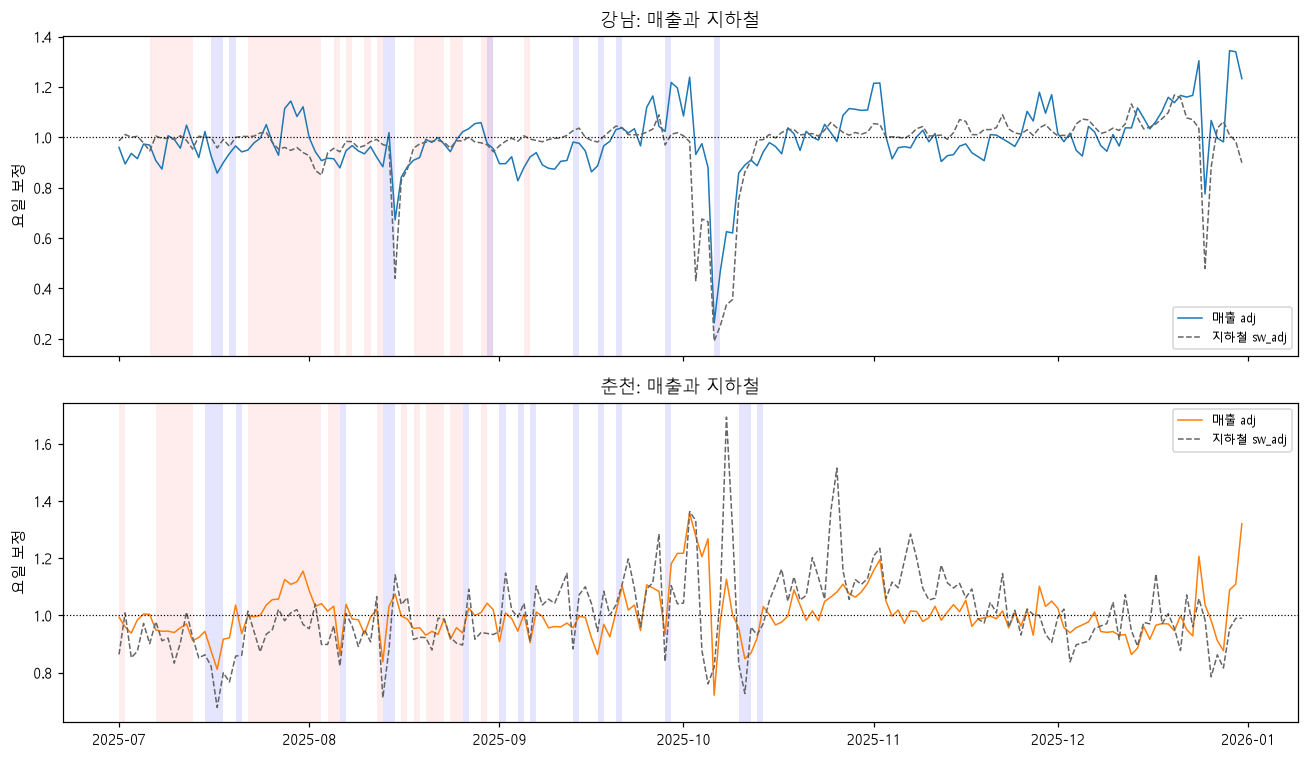

,그냥 상관,요일 보정 상관,여름 상관,지하철 폭염 효과,지하철 비 효과
region,,,,,
강남,0.730,0.370,0.280,0.980,1.000
춘천,0.570,0.520,0.540,0.930,0.910


In [28]:
sw = subway[subway['date'].between('2025-07-01', '2025-12-31')].merge(calendar, on='date')
m = sw[~sw['is_holiday']].groupby(['region', 'dow'])['total'].mean().rename('sw_dow')
sw = sw.merge(m, on=['region', 'dow'], how='left')
sw['sw_adj'] = sw['total'] / sw['sw_dow']
daily = daily.merge(sw[['date', 'region', 'total', 'sw_adj']], on=['date', 'region'], how='left')

print('하루 평균 승하차:', daily.groupby('region')['total'].mean().round(0).to_dict())

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, r in zip(axes, REGIONS):
    g = daily[daily['region'].eq(r)]
    ax.plot(g['date'], g['adj'], color=REGION_COLOR[r], lw=1, label='매출 adj')
    ax.plot(g['date'], g['sw_adj'], color='0.4', lw=1, ls='--', label='지하철 sw_adj')
    for d in g.loc[g['heat33'], 'date']:
        ax.axvspan(d, d + pd.Timedelta(days=1), color='red', alpha=0.07, lw=0)
    for d in g.loc[g['rain30'], 'date']:
        ax.axvspan(d, d + pd.Timedelta(days=1), color='blue', alpha=0.10, lw=0)
    ax.axhline(1, ls=':', color='k', lw=0.8)
    ax.set(ylabel='요일 보정', title=f'{r}: 매출과 지하철'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

행 = []
for r in REGIONS:
    g = daily[daily['region'].eq(r)]
    ok = g[g['ok']]
    s = ok[ok['summer']]
    h, w = effect(s, 'sw_adj')
    행.append({'region': r, '그냥 상관': g['amt'].corr(g['total']),
               '요일 보정 상관': ok['adj'].corr(ok['sw_adj']), '여름 상관': s['adj'].corr(s['sw_adj']),
               '지하철 폭염 효과': h, '지하철 비 효과': w})
display(pd.DataFrame(행).set_index('region').round(2))

### 6-3. (6-c) 외지인 매출 비중

In [29]:
out = (outsider.groupby(['date', 'region'], as_index=False)
       .agg(amount_total=('amount_total', 'sum'), amount_outsider=('amount_outsider', 'sum')))
out['share'] = out['amount_outsider'] / out['amount_total']
out = out.merge(calendar, on='date').merge(wx[['date', 'region', 'rain', 'heat33']], on=['date', 'region'])
out['ok'] = ~out['is_holiday'] & ~out['is_chuseok_break']
out['summer'] = out['month'].between(7, 9)
out['dry'], out['wet'] = out['rain'] < 1, out['rain'] >= 5


def 날유형(d):
    if d['wet']:
        return '비 온 날'
    return '마른 폭염일' if d['heat33'] else '마른 비폭염일'


s = out[out['summer'] & out['ok']].copy()
s['유형'] = s.apply(날유형, axis=1)
print('외지인 매출 비중 (여름, ok인 날)')
display(s.pivot_table(index=['region', 'is_offday'], columns='유형', values='share',
                      aggfunc=['mean', 'size']).round(3))

행 = []
for r in REGIONS:
    g = out[out['region'].eq(r)].copy()
    g['local'] = g['amount_total'] - g['amount_outsider']
    for col, 이름 in [('amount_outsider', '외지인'), ('local', '현지인')]:
        m = g[~g['is_holiday']].groupby('dow')[col].mean()
        g['adj'] = g[col] / g['dow'].map(m)
        h, w = effect(g[g['summer'] & g['ok']])
        행.append({'region': r, '구분': 이름, '폭염 효과': h, '비 효과': w})
display(pd.DataFrame(행).pivot(index='구분', columns='region', values=['폭염 효과', '비 효과']).round(2))

외지인 매출 비중 (여름, ok인 날)


mean                 size             
유형               마른 비폭염일 마른 폭염일 비 온 날 마른 비폭염일 마른 폭염일 비 온 날
region is_offday                                          
강남     False       0.480  0.475 0.475      26     25    14
       True        0.488  0.486 0.479      12      7     7
춘천     False       0.167  0.168 0.156      25     22    18
       True        0.238  0.246 0.212      12      6     8

폭염 효과        비 효과      
region    강남    춘천    강남    춘천
구분                            
외지인    1.000 1.030 0.950 0.860
현지인    1.010 0.990 0.960 0.950

**분기** (해당하는 것 모두 체크)
- [x] 건수가 줄었다 -> 내점 자체가 차단
- [ ] 객단가가 줄었다 (건수 유지) -> 나왔지만 덜 씀
- [x] 지하철과 매출이 같이 빠졌다 -> 유동 감소가 원인 **(춘천만)**
- [x] 지하철은 그대로인데 매출만 빠졌다 -> 와서 덜 쓰거나 다른 곳에서 씀 **(강남만)**
- [ ] (춘천) 외지인이 먼저 빠진다 / [x] 아니다 (폭염에는 아니고, **비 올 때만** 먼저 빠짐)

다음으로 갈 곳: **7장 (Q7)**

### Q6 정리
- **본 것**: 건수와 객단가 분해(6-1), 지하철 겹치기(6-2), 외지인 비중(6-3)
- **나온 것**:
  - 비 효과는 **거의 전부 건수**다. 금액 0.96 = 건수 0.95 x 객단가 1.01 (강남), 0.93 = 0.93 x 1.00 (춘천)
  - 업종별로는 경로가 다르다. 춘천 골프장 폭염은 건수(0.86)와 객단가(0.88) **둘 다**, 강남 의복/의류 폭염은 객단가(0.94)만
  - 지하철: **강남은 비가 와도 그대로(1.00)인데 매출은 0.96** / 춘천은 지하철도 같이 빠진다(0.91)
  - 외지인: 춘천 비 효과가 외지인 0.86 vs 현지인 0.95로 **비 올 때는 외지인이 먼저 빠진다.** 폭염에는 1.03으로 오히려 안 빠짐
- **시사점**:
  - **두 지역의 메커니즘이 다르다.** 강남은 "나왔는데 덜 쓰거나 다른 데서 씀", 춘천은 "아예 안 옴"
  - 춘천은 외지인 의존이 비에 취약한 고리다. 강남은 외지인 비중이 어느 날이든 47~49%로 변화가 없다

## 7. Q7 순손실인가 시점 이동인가 (게이트)
**게이트**이다. 음성이면 회복 곡선 주제 자체가 성립하지 않으므로, Q8에 들어가기 전에 통과시켜야 한다.
- **순손실**: 충격 날 줄어든 매출이 그냥 사라짐 -> 앞뒤 날을 합쳐도 평소보다 적음
- **시점 이동**: 충격 날 안 산 것을 앞뒤 날에 몰아서 삼 -> 앞뒤 날을 합치면 평소와 같음

> [추론] 2025년 여름이 연속적이면 ±7일 창이 다음 구간과 겹쳐 7-b 계산이 불가능해진다. 명세서 05번의 t-7 ~ t+14는 여기서 검증한 뒤에 확정한다. (기획 문서)

### 7-1. (7-a) 폭염 연속 구간 목록

In [30]:
heat_sp = wx_events[wx_events['event'].eq('heat33')]
for r in REGIONS:
    t = heat_sp[heat_sp['region'].eq(r)]
    print(f"{r}: {len(t)}구간 ({t['length_days'].sum()}일)")
    display(t[['spell_id', 'start', 'end', 'length_days', 'gap_to_prev_days']].round(0).T)

# 확인: wx의 heat33에서 직접 다시 뽑아도 같은가
for r in REGIONS:
    g = wx[wx['region'].eq(r)].sort_values('date')
    run = (g['heat33'] != g['heat33'].shift()).cumsum()
    직접 = g[g['heat33']].groupby(run[g['heat33']])['date'].agg(['min', 'max'])
    t = heat_sp[heat_sp['region'].eq(r)]
    print(f'{r}: 직접 뽑은 구간 {len(직접)}개, wx_events {len(t)}개, 시작일 일치',
          list(직접['min']) == list(t['start']))

강남: 10구간 (33일)


,0,1,2,3,4,5,6,7,8,9
spell_id,1,2,3,4,5,6,7,8,9,10
start,2025-07-06 00:00:00,2025-07-22 00:00:00,2025-08-05 00:00:00,2025-08-07 00:00:00,2025-08-10 00:00:00,2025-08-12 00:00:00,2025-08-18 00:00:00,2025-08-24 00:00:00,2025-08-29 00:00:00,2025-09-05 00:00:00
end,2025-07-12 00:00:00,2025-08-02 00:00:00,2025-08-05 00:00:00,2025-08-07 00:00:00,2025-08-10 00:00:00,2025-08-12 00:00:00,2025-08-22 00:00:00,2025-08-25 00:00:00,2025-08-30 00:00:00,2025-09-05 00:00:00
length_days,7,12,1,1,1,1,5,2,2,1
gap_to_prev_days,<NA>,9,2,1,2,1,5,1,3,5


춘천: 10구간 (30일)


,19,20,21,22,23,24,25,26,27,28
spell_id,1,2,3,4,5,6,7,8,9,10
start,2025-07-01 00:00:00,2025-07-07 00:00:00,2025-07-22 00:00:00,2025-08-04 00:00:00,2025-08-12 00:00:00,2025-08-16 00:00:00,2025-08-18 00:00:00,2025-08-20 00:00:00,2025-08-24 00:00:00,2025-08-29 00:00:00
end,2025-07-01 00:00:00,2025-07-12 00:00:00,2025-08-02 00:00:00,2025-08-05 00:00:00,2025-08-12 00:00:00,2025-08-16 00:00:00,2025-08-18 00:00:00,2025-08-22 00:00:00,2025-08-25 00:00:00,2025-08-29 00:00:00
length_days,1,6,12,2,1,1,1,3,2,1
gap_to_prev_days,<NA>,5,9,1,6,3,1,1,1,3


강남: 직접 뽑은 구간 10개, wx_events 10개, 시작일 일치 True
춘천: 직접 뽑은 구간 10개, wx_events 10개, 시작일 일치 True


### 7-2. 구간 사이 간격과 깨끗한 창 수

강남 폭염 간격 중앙값 2일, 7일 이하 8/9개
춘천 폭염 간격 중앙값 3일, 7일 이하 8/9개


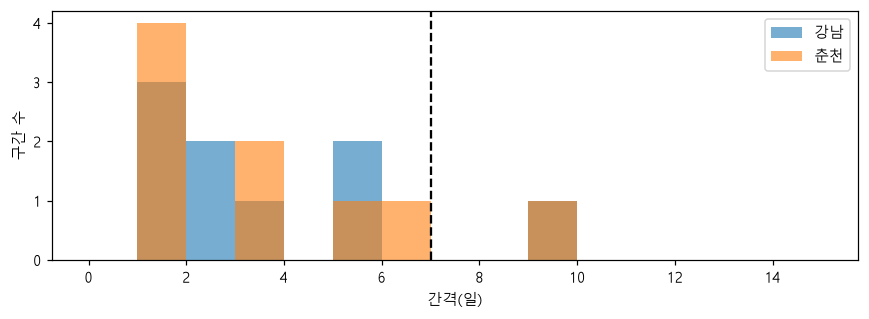

n=1  n=2  n=3  n=5  n=7  n=14
event  region                               
heat33 강남       10    4    3    2    0     0
       춘천        9    3    3    1    0     0
rain30 강남        9    7    5    4    4     1
       춘천       14   10    5    4    1     0

간격 2일 이하를 합치면: {'강남 heat33': '10 -> 5구간', '강남 rain30': '9 -> 7구간', '춘천 heat33': '10 -> 6구간', '춘천 rain30': '14 -> 9구간'}


In [31]:
fig, ax = plt.subplots(figsize=(8, 3))
for r in REGIONS:
    간격 = heat_sp.loc[heat_sp['region'].eq(r), 'gap_to_prev_days'].dropna()
    ax.hist(간격, bins=range(0, 16), alpha=0.6, color=REGION_COLOR[r], label=r)
    print(f'{r} 폭염 간격 중앙값 {간격.median():.0f}일, 7일 이하 {int((간격 <= 7).sum())}/{len(간격)}개')
ax.axvline(7, ls='--', color='k'); ax.set(xlabel='간격(일)', ylabel='구간 수'); ax.legend()
plt.tight_layout(); plt.show()


def 깨끗한창(event, n):
    """구간 앞뒤 n일 안에 다른 같은 이벤트 날이 없고, 창이 분석 기간 안에 드는 구간 수."""
    수 = {}
    for r in REGIONS:
        sp = wx_events[(wx_events['region'] == r) & (wx_events['event'] == event)]
        날 = set(wx.loc[wx['region'].eq(r) & wx[event], 'date'])
        c = 0
        for _, s in sp.iterrows():
            lo, hi = s['start'] - pd.Timedelta(days=n), s['end'] + pd.Timedelta(days=n)
            if lo < pd.Timestamp('2025-07-01') or hi > pd.Timestamp('2025-12-31'):
                continue
            바깥 = [d for d in 날 if lo <= d <= hi and not (s['start'] <= d <= s['end'])]
            c += (len(바깥) == 0)
        수[r] = c
    return 수


행 = []
for event in ['heat33', 'rain30']:
    for r in REGIONS:
        행.append({'event': event, 'region': r,
                   **{f'n={n}': 깨끗한창(event, n)[r] for n in [1, 2, 3, 5, 7, 14]}})
display(pd.DataFrame(행).set_index(['event', 'region']))

합치기 = {}
for (r, e), g in wx_events.groupby(['region', 'event']):
    합치기[f'{r} {e}'] = f"{len(g)} -> {(g['gap_to_prev_days'].fillna(999) > 2).cumsum().nunique()}구간"
print('간격 2일 이하를 합치면:', 합치기)

**결정**: 이벤트 창 길이 n을 적어 둔다.

- **결정**: **폭염 n=3(깨끗한 구간 강남 3, 춘천 3), 호우 n=3(강남 5, 춘천 5).** ±7일은 폭염에 쓸 수 없다.
- **이유**: 폭염 구간 사이 간격의 중앙값이 강남 2일, 춘천 3일이라 n=7이면 깨끗한 구간이 **0개**가 된다.
  n=3이면 지역마다 3개가 남고, n=2로 늘리면 4개와 3개다. 표본이 3~5개뿐이라는 한계를 결과에 반드시 함께 적는다.

### 7-3. (7-b) 충격 구간 ±n일 누적 매출

In [32]:
기준선 = {}
for r in REGIONS:
    g = daily[daily['region'].eq(r) & daily['summer'] & daily['ok']]
    평상 = g[~g['heat33'] & ~g['wet']]
    기준선[r] = 평상['adj'].mean()
    print(f'{r} 기준선(평상 수준) {기준선[r]:.3f} ({len(평상)}일)')


def 누적비율(event, n):
    행 = []
    for r in REGIONS:
        sp = wx_events[(wx_events['region'] == r) & (wx_events['event'] == event)]
        날 = set(wx.loc[wx['region'].eq(r) & wx[event], 'date'])
        d = daily[daily['region'].eq(r)].set_index('date')
        for _, s in sp.iterrows():
            lo, hi = s['start'] - pd.Timedelta(days=n), s['end'] + pd.Timedelta(days=n)
            if lo < pd.Timestamp('2025-07-01') or hi > pd.Timestamp('2025-12-31'):
                continue
            if [x for x in 날 if lo <= x <= hi and not (s['start'] <= x <= s['end'])]:
                continue
            창 = d.loc[lo:hi]
            행.append({'region': r, '시작': s['start'].date(), '길이': s['length_days'],
                       '앞 n일': d.loc[lo:s['start'] - pd.Timedelta(days=1), 'adj'].mean(),
                       '구간 중': d.loc[s['start']:s['end'], 'adj'].mean(),
                       '뒤 n일': d.loc[s['end'] + pd.Timedelta(days=1):hi, 'adj'].mean(),
                       '누적 비율': 창['adj'].sum() / (기준선[r] * len(창)),
                       '휴일 걸림': bool((창['is_holiday'] | 창['is_chuseok_break']).any())})
    return pd.DataFrame(행)


for n in [3, 2]:
    t = 누적비율('heat33', n)
    print(f'\n폭염, n={n}'); display(t.round(2))
    print('지역 평균 누적 비율:', t.groupby('region')['누적 비율'].mean().round(2).to_dict())

강남 기준선(평상 수준) 0.973 (38일)
춘천 기준선(평상 수준) 1.011 (37일)

폭염, n=3


,region,시작,길이,앞 n일,구간 중,뒤 n일,누적 비율,휴일 걸림
0,강남,2025-07-06,7,0.940,0.960,0.970,0.990,False
1,강남,2025-08-29,2,1.040,1.020,0.920,1.010,False
2,강남,2025-09-05,1,0.880,0.880,0.920,0.920,False
3,춘천,2025-07-07,6,1.000,0.950,0.930,0.950,False
4,춘천,2025-08-12,1,0.970,1.020,0.980,0.970,True
5,춘천,2025-08-29,1,0.990,1.010,0.990,0.980,False


지역 평균 누적 비율: {'강남': 0.97, '춘천': 0.97}



폭염, n=2


,region,시작,길이,앞 n일,구간 중,뒤 n일,누적 비율,휴일 걸림
0,강남,2025-07-06,7,0.940,0.960,0.950,0.980,False
1,강남,2025-07-22,12,0.950,1.020,0.910,1.030,False
2,강남,2025-08-29,2,1.040,1.020,0.920,1.020,False
3,강남,2025-09-05,1,0.880,0.880,0.930,0.920,False
4,춘천,2025-07-07,6,1.000,0.950,0.920,0.940,False
5,춘천,2025-08-12,1,0.960,1.020,0.930,0.950,False
6,춘천,2025-08-29,1,1.010,1.010,1.030,1.010,False


지역 평균 누적 비율: {'강남': 0.99, '춘천': 0.97}


### 7-4. 호우 구간으로 같은 계산

In [33]:
for n in [3, 2]:
    t = 누적비율('rain30', n)
    print(f'호우, n={n} (구간 {len(t)}개)'); display(t.round(2))
    print('지역 평균 누적 비율:', t.groupby('region')['누적 비율'].mean().round(2).to_dict())
    print('  휴일이 안 걸린 구간만:', t[~t['휴일 걸림']].groupby('region')['누적 비율'].mean().round(2).to_dict())

호우, n=3 (구간 10개)


,region,시작,길이,앞 n일,구간 중,뒤 n일,누적 비율,휴일 걸림
0,강남,2025-08-13,2,0.940,0.950,0.800,0.910,True
1,강남,2025-08-30,1,1.050,0.980,0.920,1.010,False
2,강남,2025-09-13,1,0.900,0.980,0.930,0.950,False
3,강남,2025-09-28,1,1.110,1.020,1.170,1.150,False
4,강남,2025-10-06,1,0.930,0.260,0.570,0.700,True
5,춘천,2025-08-06,1,1.030,0.860,1.000,0.980,False
6,춘천,2025-08-13,2,0.980,0.930,1.020,0.970,True
7,춘천,2025-08-26,1,0.950,0.940,1.010,0.970,False
8,춘천,2025-09-13,1,0.960,0.960,0.970,0.960,False
9,춘천,2025-09-28,1,1.100,0.930,1.200,1.110,False


지역 평균 누적 비율: {'강남': 0.94, '춘천': 1.0}
  휴일이 안 걸린 구간만: {'강남': 1.04, '춘천': 1.0}
호우, n=2 (구간 17개)


,region,시작,길이,앞 n일,구간 중,뒤 n일,누적 비율,휴일 걸림
0,강남,2025-08-13,2,0.940,0.950,0.760,0.910,True
1,강남,2025-08-30,1,1.060,0.980,0.920,1.010,False
2,강남,2025-09-13,1,0.910,0.980,0.960,0.970,False
3,강남,2025-09-17,1,0.900,0.890,0.980,0.950,False
4,강남,2025-09-20,1,0.980,1.030,1.030,1.030,False
5,강남,2025-09-28,1,1.100,1.020,1.210,1.160,False
6,강남,2025-10-06,1,0.930,0.260,0.550,0.660,True
7,춘천,2025-07-15,3,0.920,0.880,0.920,0.890,False
8,춘천,2025-07-20,1,0.920,1.040,0.970,0.950,False
9,춘천,2025-08-06,1,1.020,0.860,1.010,0.980,False


지역 평균 누적 비율: {'강남': 0.96, '춘천': 0.97}
  휴일이 안 걸린 구간만: {'강남': 1.03, '춘천': 0.97}


### 7-5. 창이 겹칠 때 대안: 여름 종료 전환 한 번

강남: 마지막 폭염일 2025-09-05 | 앞 14일 0.96 -> 뒤 14일 0.92
춘천: 마지막 폭염일 2025-08-29 | 앞 14일 0.97 -> 뒤 14일 0.98


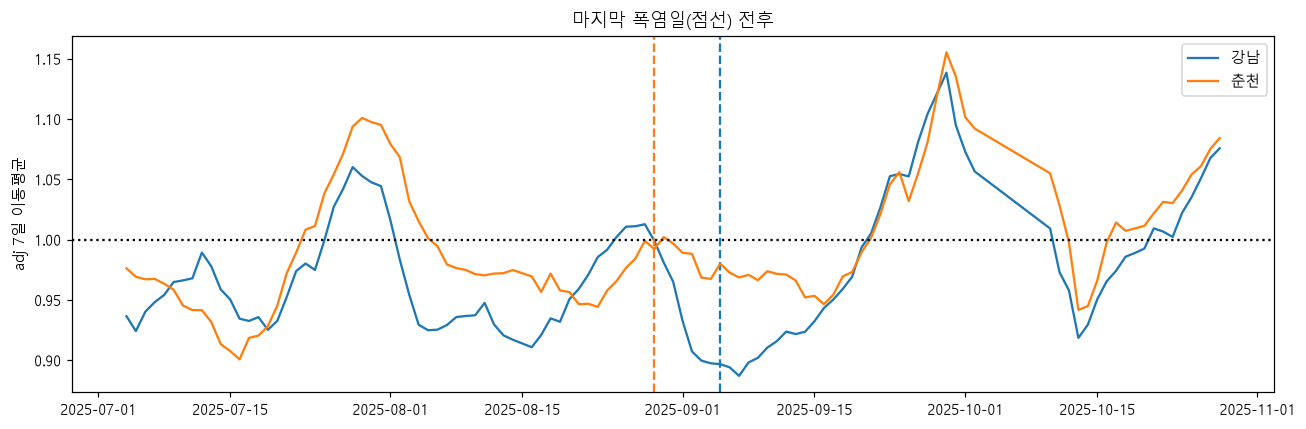

In [34]:
fig, ax = plt.subplots(figsize=(12, 4))
for r in REGIONS:
    g = daily[daily['region'].eq(r) & daily['ok'] & daily['date'].between('2025-07-01', '2025-10-31')]
    ax.plot(g['date'], g['adj'].rolling(7, center=True).mean(), color=REGION_COLOR[r], label=r)
    마지막 = wx.loc[wx['region'].eq(r) & wx['heat33'], 'date'].max()
    ax.axvline(마지막, ls='--', color=REGION_COLOR[r])
    앞 = daily[daily['region'].eq(r) & daily['ok'] & daily['date'].between(마지막 - pd.Timedelta(days=14), 마지막)]
    뒤 = daily[daily['region'].eq(r) & daily['ok'] & daily['date'].between(마지막 + pd.Timedelta(days=1), 마지막 + pd.Timedelta(days=14))]
    print(f"{r}: 마지막 폭염일 {마지막.date()} | 앞 14일 {앞['adj'].mean():.2f} -> 뒤 14일 {뒤['adj'].mean():.2f}")
ax.axhline(1, ls=':', color='k'); ax.set(ylabel='adj 7일 이동평균', title='마지막 폭염일(점선) 전후')
ax.legend(); plt.tight_layout(); plt.show()

**결정**: 게이트 결과를 적어 둔다.

- **결정**: **폭염은 판정 보류(구간 3개뿐), 호우는 시점 이동에 가깝다.**
- **이유**: 폭염 n=3의 누적 비율이 두 지역 모두 평균 0.97로 3% 적지만, 구간이 3개뿐이라 순손실이라고 단정할 수 없다.
  호우는 휴일이 걸리지 않은 구간만 보면 강남 1.04, 춘천 1.00이고, **다음 날(lag +1)에 바로 1.00 위로 올라온다.**
  당일 줄어든 만큼이 다음 날들에 채워지는 모양이다.

**분기** (하나 체크)
- [ ] 누적이 줄었다 -> 순손실. Q8로
- [x] 누적이 같다 -> 시점 이동. 지수의 전제가 바뀌므로 교수님과 상의 **(호우)**
- [x] 창이 겹쳐 계산 불가 -> 여름 종료 시점 한 번의 전환만 보는 쪽으로 (7-5) **(폭염)**

다음으로 갈 곳: **8장 (Q8)** — 단, 호우 중심으로. 폭염은 모양만 본다.

### Q7 정리
- **본 것**: 폭염 구간 목록(7-1), 깨끗한 창 수(7-2), 누적 매출(7-3, 7-4), 여름 종료 전환(7-5)
- **나온 것**:
  - 깨끗한 창 수: 폭염은 n=3에서 3개, **n=7에서 0개**. 호우는 n=3에서 5개, n=7에서 강남 4개 춘천 1개
  - 폭염 n=3 누적 비율 평균 0.97(두 지역 모두). n=2로 늘리면 강남 0.99, 춘천 0.97
  - 호우 n=3 누적 비율은 강남 0.94, 춘천 1.00인데 **강남의 0.94는 추석(10/6, 0.70)과 광복절 구간이 끌어내린 값**이다. 빼면 1.04
  - 마지막 폭염일 전후 14일: 강남 0.96 → 0.92, 춘천 0.97 → 0.98로 **여름이 끝나도 튀지 않는다**
- **시사점**:
  - **게이트를 폭염으로는 통과시킬 수 없다.** 구간이 3개뿐이고 창이 겹친다
  - 호우는 시점 이동 쪽이다. "억눌린 소비가 뒤에 몰린다"는 회복 곡선의 전제가 **호우에서는 약하게 성립**하고 폭염에서는 확인할 수 없다
  - 창 안에 휴일이 걸리면 결과가 크게 흔들린다(10/6 추석 구간 0.70). 휴일이 걸린 구간은 따로 표시해야 한다

## 8. Q8 회복
**Q7을 통과했을 때만** 한다. 충격 종료일을 0으로 맞추고 이후 매출 궤적을 본다.
볼 것: 기준선 복귀에 며칠 걸리는가, 업종별로 다른가, 미뤄진 소비가 몰려 오히려 튀는가. 동시에 지하철 궤적을 겹쳐 **유동 회복과 매출 회복의 시차**를 본다.

### 8-1. 가장 긴 폭염 구간(7/22~8/2) 전후 궤적

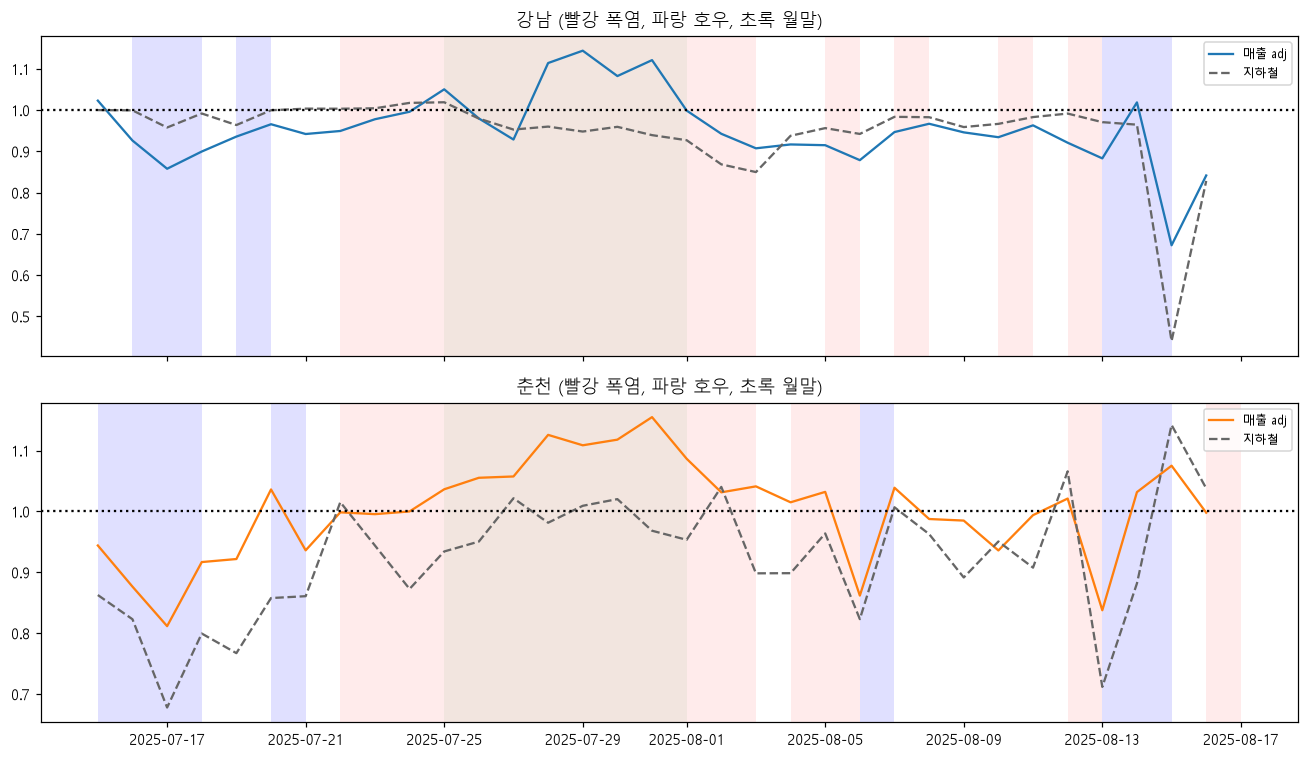

,앞 7일 매출,구간 중 매출,뒤 7일 매출,앞 7일 지하철,구간 중 지하철,뒤 7일 지하철
region,,,,,,
강남,0.940,1.020,0.930,0.990,0.960,0.940
춘천,0.920,1.060,0.990,0.810,0.980,0.920


In [35]:
창 = daily[daily['date'].between('2025-07-15', '2025-08-16')]
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, r in zip(axes, REGIONS):
    g = 창[창['region'].eq(r)]
    ax.plot(g['date'], g['adj'], color=REGION_COLOR[r], label='매출 adj')
    ax.plot(g['date'], g['sw_adj'], color='0.4', ls='--', label='지하철')
    for d in g.loc[g['heat33'], 'date']:
        ax.axvspan(d, d + pd.Timedelta(days=1), color='red', alpha=0.08, lw=0)
    for d in g.loc[g['rain30'], 'date']:
        ax.axvspan(d, d + pd.Timedelta(days=1), color='blue', alpha=0.12, lw=0)
    for d in g.loc[g['date'].dt.day >= 25, 'date']:
        ax.axvspan(d, d + pd.Timedelta(days=1), color='green', alpha=0.05, lw=0)
    ax.axhline(1, ls=':', color='k'); ax.set(title=f'{r} (빨강 폭염, 파랑 호우, 초록 월말)'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

구간 = {'앞 7일': ('2025-07-15', '2025-07-21'), '구간 중': ('2025-07-22', '2025-08-02'),
        '뒤 7일': ('2025-08-03', '2025-08-09')}
행 = []
for r in REGIONS:
    g = daily[daily['region'].eq(r)].set_index('date')
    행.append({'region': r, **{f'{k} 매출': g.loc[a:b, 'adj'].mean() for k, (a, b) in 구간.items()},
               **{f'{k} 지하철': g.loc[a:b, 'sw_adj'].mean() for k, (a, b) in 구간.items()}})
display(pd.DataFrame(행).set_index('region').round(2))

### 8-2. 호우일 전후 평균 궤적

호우 전후 매출


lag,-3,-2,-1,0,1,2,3,4,5
region,,,,,,,,,
강남,0.966,0.972,0.963,0.955,1.002,0.970,0.963,0.971,0.961
춘천,0.964,0.971,0.972,0.930,1.007,0.991,1.008,1.006,0.991


구간 수


lag,-3,-2,-1,0,1,2,3,4,5
region,,,,,,,,,
강남,8,8,8,8,7,8,8,9,8
춘천,13,13,13,14,13,14,14,14,13


호우 전후 지하철


lag,-3,-2,-1,0,1,2,3,4,5
region,,,,,,,,,
강남,0.990,0.990,1.010,0.990,1.000,0.980,0.990,0.970,0.980
춘천,0.950,0.970,1.000,0.890,1.030,1.000,1.010,1.020,1.020


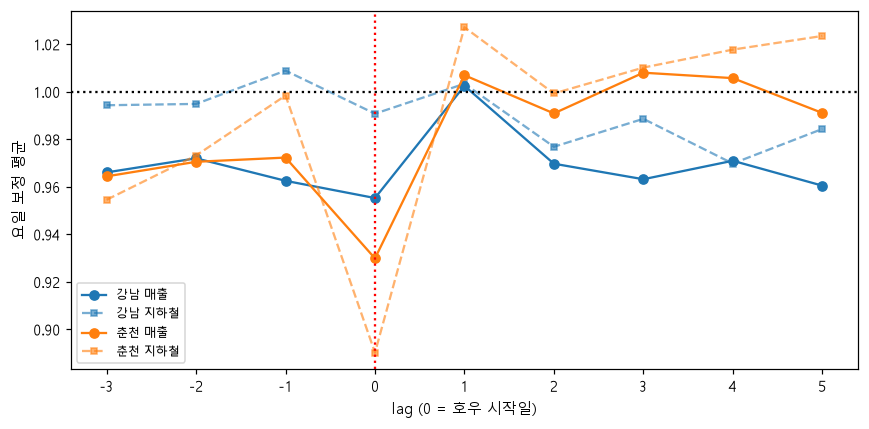

In [36]:
def lag표(event, 값='adj', df=None, lags=range(-3, 6)):
    """이벤트 구간마다 lag별 값을 모아 평균을 낸다. lag<=0은 시작일 기준, lag>=1은 종료일 기준."""
    행 = []
    for r in REGIONS:
        sp = wx_events[(wx_events['region'] == r) & (wx_events['event'] == event)]
        d = (df if df is not None else daily)
        d = d[d['region'].eq(r)].set_index('date')
        for _, s in sp.iterrows():
            for k in lags:
                날 = s['start'] + pd.Timedelta(days=k) if k <= 0 else s['end'] + pd.Timedelta(days=k)
                if 날 not in d.index:
                    continue
                row = d.loc[날]
                if row['is_holiday'] or row['is_chuseok_break']:
                    continue
                행.append({'region': r, 'lag': k, '값': row[값]})
    t = pd.DataFrame(행)
    return t.groupby(['region', 'lag'])['값'].agg(mean='mean', n='size').reset_index()


매출 = lag표('rain30', 'adj')
지하철 = lag표('rain30', 'sw_adj')
print('호우 전후 매출'); display(매출.pivot(index='region', columns='lag', values='mean').round(3))
print('구간 수'); display(매출.pivot(index='region', columns='lag', values='n'))
print('호우 전후 지하철'); display(지하철.pivot(index='region', columns='lag', values='mean').round(2))

fig, ax = plt.subplots(figsize=(8, 4))
for r in REGIONS:
    t = 매출[매출['region'].eq(r)]
    ax.plot(t['lag'], t['mean'], marker='o', color=REGION_COLOR[r], label=f'{r} 매출')
    t2 = 지하철[지하철['region'].eq(r)]
    ax.plot(t2['lag'], t2['mean'], marker='s', ms=4, ls='--', color=REGION_COLOR[r], alpha=0.6, label=f'{r} 지하철')
ax.axhline(1, ls=':', color='k'); ax.axvline(0, ls=':', color='r')
ax.set(xlabel='lag (0 = 호우 시작일)', ylabel='요일 보정 평균'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 8-3. 업종별 회복

lag                   -3    -2    -1     0     1     2     3     4     5
region industry                                                         
강남     기타식품        1.020 1.050 0.860 0.870 1.010 0.940 1.010 0.880 0.970
       스포츠/레저용품    1.000 0.900 0.930 0.960 1.020 0.900 0.890 0.910 0.880
       의복/의류       1.150 1.040 1.270 1.140 1.000 0.880 0.890 0.920 0.890
춘천     실내/실외골프장    0.980 1.200 1.190 0.760 1.350 1.250 1.270 1.230 1.340
       종합레저타운/놀이동산 0.960 1.030 1.110 0.790 1.030 1.000 1.010 1.040 1.200
       커피전문점       0.980 1.010 0.970 0.870 1.060 0.970 1.020 1.010 1.010

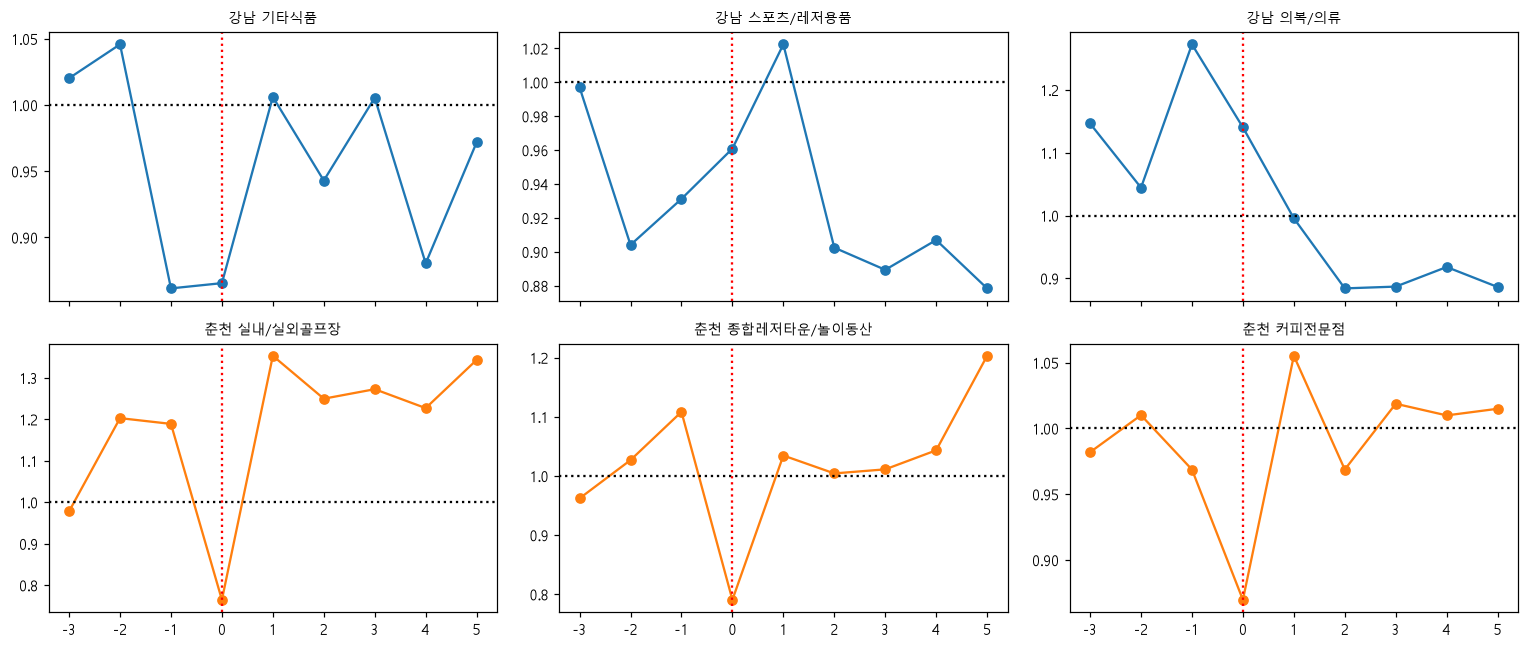

In [37]:
행 = []
for r, inds in SEL.items():
    for ind in inds:
        d = daily_ind[(daily_ind['region'] == r) & (daily_ind['industry'] == ind)]
        t = lag표('rain30', 'adj', df=d)
        t = t[t['region'].eq(r)].assign(industry=ind)
        행.append(t)
업종lag = pd.concat(행)
display(업종lag.pivot_table(index=['region', 'industry'], columns='lag', values='mean').round(2))

fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharex=True)
for ax, ((r, ind), g) in zip(axes.ravel(), 업종lag.groupby(['region', 'industry'])):
    ax.plot(g['lag'], g['mean'], marker='o', color=REGION_COLOR[r])
    ax.axhline(1, ls=':', color='k'); ax.axvline(0, ls=':', color='r')
    ax.set_title(f'{r} {ind}', fontsize=9)
plt.tight_layout(); plt.show()

**분기** (해당하는 것 모두 체크)
- [x] 기준선 복귀까지 ( **1** )일
- [x] 업종별로 다르다 -> 즉시회복 / 지연회복 / 미회복 유형화 (05번 event study)
- [x] 미뤄진 소비가 몰려 튄다 (반등) **(춘천 골프장 1.35)** / [ ] 튀지 않는다
- [ ] 유동 회복과 매출 회복 사이 시차가 있다 / [x] 없다

다음으로 갈 곳: **9장 (Q9)**

### Q8 정리
- **본 것**: 가장 긴 폭염 구간 전후(8-1), 호우 전후 평균 궤적(8-2), 업종별 회복(8-3)
- **나온 것**:
  - 가장 긴 폭염 구간(7/22~8/2)은 **구간 중 매출이 오히려 높다**(강남 1.02, 춘천 1.06). 앞 7일이 집중호우, 구간 끝이 월말이라 생긴 모양이다
  - 호우는 **다음 날 바로 회복**한다. lag 0에서 강남 0.955 춘천 0.930 → lag +1에서 1.002, 1.007
  - 지하철도 같은 모양이다(춘천 lag 0에서 0.89 → lag +1에서 1.03). **유동과 매출이 같이 빠지고 같이 돌아온다**
  - 업종별로 다르다. 춘천 골프장은 lag 0에서 0.76으로 떨어졌다가 **lag +1에서 1.35로 크게 튄다**(미뤄진 예약으로 보임)
  - 강남 의복/의류는 비에 반응하지 않는다(lag 0에서 1.14)
- **시사점**:
  - **회복은 하루면 끝난다.** "며칠에 걸친 회복 곡선"이라는 그림은 이 데이터의 호우에서는 나오지 않는다
  - > [추론] 춘천 골프장의 lag +1 반등(1.35)은 비로 미뤄진 예약이 다음 날 몰린 것으로 보인다. 예약 데이터가 없어 확인은 불가능하다
  - 8-1의 "폭염 중 매출이 높다"는 폭염 효과가 아니라 **호우와 월말이 만든 착시**다. 05번 회귀에서 월말을 통제해야 한다

## 9. Q9 강남과 춘천
Q3~Q8을 한 번씩 돌린 뒤 **나란히** 놓는다. 처음부터 따로 볼 필요 없다.
볼 것: 같은 방향인가. 크기만 다른가, 부호가 다른가.

> 두 지역이 같은 방향이면 그게 근거이다. 클러스터가 2개뿐이라 유의성 검정으로는 말할 수 있는 게 없고, 복제(replication) 여부가 유일하게 정직한 증거이다. (기획 문서)

### 9-1. 핵심 숫자 나란히 놓기

In [38]:
def 값(r, event, col='adj'):
    g = daily[daily['region'].eq(r) & daily['summer'] & daily['ok']]
    return effect(g, col)


행 = {}
for r in REGIONS:
    h, w = 값(r, 'heat33')
    hc, wc = 값(r, 'heat33', 'cnt_adj')
    hs, ws = 값(r, 'heat33', 'sw_adj')
    g = daily[daily['region'].eq(r) & daily['ok']]
    행[r] = {'폭염 효과': h, '비 효과': w, '비 효과(건수)': wc, '지하철 비 효과': ws,
             '50mm+ 평균': g.loc[g['rain'] >= 50, 'adj'].mean(),
             '호우 다음 날(lag +1)': 매출.loc[(매출['region'] == r) & (매출['lag'] == 1), 'mean'].iat[0]}
요약 = pd.DataFrame(행)
요약['같은 방향'] = np.where(np.sign(요약['강남'] - 1) == np.sign(요약['춘천'] - 1), 'O', 'X')
display(요약.round(3))
print('※ 강남 비 효과는 달(月)을 통제하면 거의 0이 된다(4-3 주의). "복제됨"은 05번 3-2 결과와 함께 판단한다.')

,강남,춘천,같은 방향
폭염 효과,1.003,0.999,X
비 효과,0.956,0.929,O
비 효과(건수),0.948,0.932,O
지하철 비 효과,1.004,0.907,X
50mm+ 평균,0.907,0.906,O
호우 다음 날(lag +1),1.002,1.007,O


※ 강남 비 효과는 달(月)을 통제하면 거의 0이 된다(4-3 주의). "복제됨"은 05번 3-2 결과와 함께 판단한다.


### 9-2. 같은 업종그룹끼리 비교

폭염 효과        비 효과      
region            강남    춘천    강남    춘천
industry_group                        
교통/차량          1.000 0.990 0.960 0.890
대형유통           1.020 1.000 0.970 0.770
미용/생활서비스       1.010 1.010 0.940 0.960
생활/취미용품        1.020 1.010 0.900 0.860
숙박/여행          1.060 1.320 1.090 0.760
스포츠시설          1.070 0.840 0.970 0.810
식료품            1.000 0.980 0.930 0.980
여가/오락          1.070 1.060 0.920 0.880
음식점            1.000 1.050 0.970 0.930
의료             1.000 0.990 0.950 0.940
주점/유흥          0.960 0.880 1.000 1.000
카페             1.010 1.080 0.940 0.830
패션/뷰티          0.970 1.080 1.040 0.820
편의점            1.020 0.990 0.980 0.940

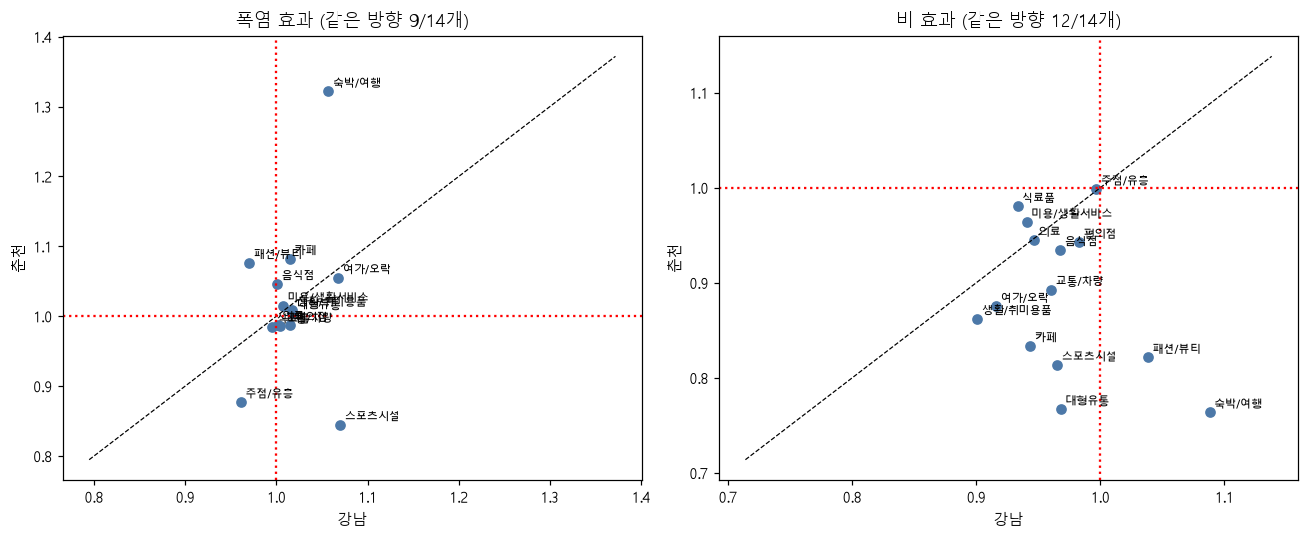

In [39]:
t = grp_eff.pivot(index='industry_group', columns='region', values=['폭염 효과', '비 효과'])
display(t.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, 지표 in zip(axes, ['폭염 효과', '비 효과']):
    x, y = t[(지표, '강남')], t[(지표, '춘천')]
    ax.scatter(x, y, color='#4C78A8')
    for ig in t.index:
        ax.annotate(ig, (x[ig], y[ig]), fontsize=7, xytext=(3, 3), textcoords='offset points')
    lim = [min(x.min(), y.min()) - 0.05, max(x.max(), y.max()) + 0.05]
    ax.plot(lim, lim, 'k--', lw=0.8); ax.axhline(1, ls=':', color='r'); ax.axvline(1, ls=':', color='r')
    같은방향 = int((((x - 1) * (y - 1)) > 0).sum())
    ax.set(xlabel='강남', ylabel='춘천', title=f'{지표} (같은 방향 {같은방향}/{len(t)}개)')
plt.tight_layout(); plt.show()

**분기** (효과마다 체크)
- [x] 같은 방향 -> 복제됨. 결론의 근거로 씀 (어떤 효과: **비 효과, 비 효과(건수), 50mm 이상 구간, 호우 다음 날 회복** )
- [x] 크기만 다르다 -> 지역 특성(외지인 비중, 업종 구성, 출퇴근)으로 설명 **(비 효과: 춘천이 더 큼)**
- [x] 부호가 다르다 -> 지역마다 다른 메커니즘. 합쳐서 결론 내지 않음 **(지하철 비 효과, 폭염 효과)**

다음으로 갈 곳: **10장 전체 정리**

### Q9 정리
- **본 것**: 핵심 숫자 나란히(9-1), 업종그룹끼리 비교(9-2)
- **나온 것**:
  - **비 효과는 복제된다.** 금액(0.96 / 0.93), 건수(0.95 / 0.93), 50mm 이상(0.91 / 0.91), 다음 날 회복(1.00 / 1.01) 모두 같은 방향
  - 업종그룹 14개 중 **12개가 두 지역 모두 비에 1 미만**이다(강남 숙박/여행 1.09, 패션/뷰티만 반대)
  - **폭염 효과는 복제되지 않는다.** 합계로 두 지역 모두 1.00이고, 업종그룹에서도 스포츠시설이 강남 1.07 / 춘천 0.84로 반대다
  - 지하철 비 효과는 강남 1.00 / 춘천 0.91로 부호가 갈린다
- **시사점**:
  - **결론으로 쓸 수 있는 것은 비 효과뿐이다.** 두 지역에서 같은 방향으로 복제됐고 업종그룹 수준에서도 12/14가 일치한다
  - 폭염은 두 지역을 합쳐 결론 내면 안 된다. 업종별로만, 지역별로만 말한다
  - > 단, 강남 비 효과는 월을 통제하면 거의 0이 될 수 있다(4-3). **05번 3-2 결과를 보고 최종 판단한다**

## 10. 전체 정리

### 10-1. 05번 노트북으로 넘길 결정 사항

| 항목 | 결정 | 근거 (몇 장) |
|---|---|---|
| 폭염 임계값 (33℃ 유지 / 다른 값) | **33℃ 유지** (데이터에 꺾임이 없어 관례를 따름) | 3-1, 3-2 |
| 기온을 임계값(더미)으로 볼지 연속 변수로 볼지 | **둘 다**. 더미(heat33)와 연속(tmax)을 나란히 돌려 결과가 같은지 확인 | 3장 |
| 열대야를 따로 볼지 (춘천은 5일뿐) | **보지 않음**. 강남도 효과가 없고(0.97 vs 0.96) 춘천은 표본 부족 | 3-4, 5-5 |
| 비 기준 (온다/안 온다 vs 양, 몇 mm부터) | **양으로 본다.** 주 기준 5mm 이상, 보조로 rain30. 구간별 계단이 뚜렷함 | 4-1 |
| 폭염과 호우의 무게 (주제의 무게중심) | **호우 중심**, 폭염은 업종 단위로만 | 4-3 |
| 반응 업종 (지역별 3~5개) | 강남 의복/의류, 스포츠/레저용품, 기타식품 / 춘천 실내/실외골프장, 종합레저타운/놀이동산, 커피전문점 | 3-3, 5-1 |
| 따로 볼 축 (시간대, 연령, 성별) | **시간대 필수**(업종마다 패턴이 다름), 연령은 보조, 성별은 생략 가능 | 5장 |
| 감소의 주 경로 (건수 / 객단가) | **건수**. 비 효과의 거의 전부가 건수 | 6-1 |
| 지하철을 같이 볼지 (통제 변수 또는 비교 궤적) | **비교 궤적으로 같이 본다.** 두 지역 메커니즘 차이가 여기서 드러남 | 6-2 |
| 춘천 외지인 분석 포함 여부 | **포함.** 비 올 때 외지인이 먼저 빠짐(0.86 vs 0.95) | 6-3 |
| 이벤트 창 길이 n (폭염, 호우 따로) | **폭염 n=3, 호우 n=3.** ±7일은 불가 | 7-2 |
| 게이트 결과 (순손실 / 시점 이동 / 계산 불가) | **폭염 계산 불가(구간 3개), 호우 시점 이동** | 7-3, 7-4 |
| 회복 분석 대상 (폭염 구간 / 호우 구간 / 여름 종료 전환) | **호우 구간 중심.** 폭염은 여름 종료 전환 한 번만 참고 | 7-5, 8장 |
| 추가로 통제할 것 (예: 월말 효과) | **월말(25일 이후) 반드시 통제.** 여름 1.06 vs 0.94로 10%p 차이 | 2-1, 8-1 |
| 두 지역 결과를 합칠지 따로 쓸지 | **비 효과만 합쳐 쓰고, 폭염은 따로.** 폭염은 업종그룹에서도 복제 안 됨 | 9장 |

### 10-2. 더 확인할 것
- 여름 25일 이후 매출이 10%p 넘게 높음(2-1) -> 05번 회귀에 **월말 변수**를 넣고 폭염 계수가 얼마나 바뀌는지 확인
- 강남 비 효과(0.96)가 월을 통제하면 사라지는지(4-3 주의) -> 05번 3-2에서 확인한 뒤 9-1의 "복제됨" 판단을 확정
- 강남 의복/의류는 7/15~7/21 요일 보정 매출이 높게 나옴 -> 여름 세일 같은 행사가 있었는지 확인 (8-3에서 lag -1이 1.27)
- > [추론] 춘천 골프장의 호우 다음 날 반등(1.35)은 미뤄진 예약으로 보이나, 예약 데이터가 없어 확인 불가
- 폭염특보(체감온도 기준)가 관측 heat33보다 매출을 더 잘 설명하는가 -> 04번 8-4의 특보 라벨로 05번에서 비교